# renquant_103 — Adaptive Regime Multi-Stock Strategy

**New vs 102**: 3-layer regime detection (Hurst + CUSUM + GMM), regime-conditional entry, relative-strength ranking, correlation-aware selection, earnings filter, defensive tickers (GLD/TLT/XLV/XLU).

In [1]:
import sys, json, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

# ROOT detection: handles Notebooks/, backtesting/renquant_103/, or repo root
_cwd = Path.cwd()
if _cwd.name == "Notebooks":
    ROOT = _cwd.parent
elif (_cwd / "strategy_config.json").exists():
    # Running from backtesting/<strategy>/ directory (e.g. nbconvert, LEAN docker)
    ROOT = _cwd.parent.parent
else:
    ROOT = _cwd  # repo root

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.colors import ListedColormap

import common
from common.data import fetch_ohlcv
# compute_indicators is NOT imported here — use kernel.indicators.compute_all in Cell 4
from common.indicators import (
    compute_hurst, rolling_hurst,
    compute_cusum, rolling_cusum,
    build_gmm_features, RegimeGMM,
)
from common.models import create_model
from common.models.scoring import fit_probability_calibration, raw_score_kind_for_model
from common.config import load_strategy_config
from common.portfolio import portfolio_stats

STRATEGY   = "renquant_103"
STRATEGY_DIR = ROOT / "backtesting" / STRATEGY
CONFIG     = load_strategy_config(STRATEGY_DIR / "strategy_config.json")
WATCHLIST  = CONFIG["watchlist"]
DEFENSIVE  = set(CONFIG.get("defensive_tickers", []))
SECTOR_ETF = CONFIG.get("sector_etf_map", {})

# Add strategy dir to path so kernel.* imports work throughout the notebook
if str(STRATEGY_DIR) not in sys.path:
    sys.path.insert(0, str(STRATEGY_DIR))

print(f"Strategy : {STRATEGY}")
print(f"ROOT     : {ROOT}")
print(f"Watchlist: {WATCHLIST}")
print(f"Defensive: {sorted(DEFENSIVE)}")

Strategy : renquant_103
ROOT     : /Users/renhao/git/github/RenQuant
Watchlist: ['TSLA', 'AMZN', 'GOOG', 'MSFT', 'AMD', 'NFLX', 'CRM', 'PLTR', 'UBER', 'NVDA', 'META', 'AAPL', 'JPM', 'UNH', 'CAT', 'BA', 'XLE', 'XLF', 'LLY', 'GLD', 'TLT', 'XLV', 'XLU']
Defensive: ['GLD', 'TLT', 'XLU', 'XLV']


## 1  Fetch OHLCV data

In [2]:
from common.config import load_strategy_config

SAMPLE_START = CONFIG["sample_start"]
SAMPLE_END   = CONFIG["sample_end"]

# All unique tickers we need: watchlist + sector ETFs + SPY
all_tickers = sorted(set(WATCHLIST) | set(SECTOR_ETF.values()) | {"SPY"})
print(f"Fetching {len(all_tickers)} tickers from {SAMPLE_START} to {SAMPLE_END}...")

ohlcv = {}
for ticker in all_tickers:
    try:
        df = fetch_ohlcv(ticker, start=SAMPLE_START, end=SAMPLE_END)
        if df is not None and not df.empty:
            ohlcv[ticker] = df
            print(f"  {ticker}: {len(df)} rows")
        else:
            print(f"  {ticker}: EMPTY")
    except Exception as e:
        print(f"  {ticker}: ERROR — {e}")

print(f"\nLoaded {len(ohlcv)} / {len(all_tickers)} tickers.")
spy_df = ohlcv["SPY"]


Fetching 26 tickers from 2016-01-01 to 2026-06-30...


  AAPL: 2587 rows


  AMD: 2587 rows


  AMZN: 2587 rows


  BA: 2587 rows


...

  XLF: 2587 rows


  XLI: 2587 rows


  XLK: 2587 rows


  XLU: 2587 rows


  XLV: 2587 rows

Loaded 26 / 26 tickers.


## 2  SPY Regime Analysis — 3-Layer Detection

In [3]:
# ── Layer 1: Rolling Hurst exponent ──────────────────────────────────────────
spy_returns = spy_df["close"].pct_change().dropna()
HURST_WINDOW = CONFIG["regime"]["hurst_window"]  # 63

hurst_series = rolling_hurst(spy_returns, window=HURST_WINDOW)
hurst_series = hurst_series.dropna()

# ── Layer 2: Rolling CUSUM changepoints ──────────────────────────────────────
cusum_series = rolling_cusum(
    spy_returns,
    window    = CONFIG["regime"]["cusum_lookback"],
    threshold = CONFIG["regime"]["cusum_threshold"],
    drift     = CONFIG["regime"]["cusum_drift"],
)

changepoint_dates = cusum_series[cusum_series].index
print(f"CUSUM detected {len(changepoint_dates)} changepoints")
print(f"Hurst range: {hurst_series.min():.3f} – {hurst_series.max():.3f}  "
      f"(mean={hurst_series.mean():.3f})")


CUSUM detected 419 changepoints
Hurst range: 0.472 – 0.875  (mean=0.702)


In [4]:
# ── Layer 3: Train GMM on SPY features ───────────────────────────────────────
gmm_features = build_gmm_features(spy_df, vol_window=20, hurst_window=HURST_WINDOW)

gmm = RegimeGMM(n_components=3, random_state=42, n_init=10)
gmm.fit(gmm_features)

print(f"GMM cluster labels (auto-assigned): {gmm.cluster_labels}")
print(f"GMM weights: {np.round(gmm._gmm.weights_, 3)}")

regime_labels, regime_probs = gmm.predict(gmm_features)
print(f"\nRegime distribution:")
print(regime_labels.value_counts())


GMM cluster labels (auto-assigned): ['BULL_CALM', 'BULL_VOLATILE', 'BEAR']
GMM weights: [0.477 0.482 0.041]

Regime distribution:
BULL_CALM        1308
BULL_VOLATILE    1167
BEAR               86
Name: count, dtype: int64


In [5]:
# ── Combine layers into final daily regime ────────────────────────────────────
BULL_CALM, BULL_VOLATILE, CHOPPY, BEAR = "BULL_CALM", "BULL_VOLATILE", "CHOPPY", "BEAR"

hurst_trend  = CONFIG["regime"]["hurst_trending_threshold"]   # 0.65
hurst_rev    = CONFIG["regime"]["hurst_reversion_threshold"]  # 0.52
vol_window   = CONFIG["regime"]["vol_realized_window"]        # 20
bear_vol_thr = CONFIG["regime"]["bear_vol_threshold"]         # 0.35
bear_ret_thr = CONFIG["regime"]["bear_return_threshold"]      # -0.08

common_idx = hurst_series.index.intersection(regime_labels.index)
final_regime      = pd.Series(index=common_idx, dtype=str)
final_regime_conf = pd.Series(index=common_idx, dtype=float)

# Precompute rolling SPY vol and return for BEAR hard override
spy_20d_vol = spy_returns.rolling(vol_window).std() * np.sqrt(252)
spy_20d_ret = spy_returns.rolling(vol_window).sum()

for date in common_idx:
    h          = hurst_series.loc[date]
    gmm_r      = regime_labels.loc[date]
    gmm_bear_p = regime_probs.loc[date].get(BEAR, 0.0)

    # Layer 1 → base regime from Hurst
    if h > hurst_trend:
        base = BULL_CALM
    elif h < hurst_rev:
        base = CHOPPY
    else:
        base = None  # ambiguous → let GMM decide

    # BEAR hard override — vol spike or sharp 20-day drawdown (GMM reacts too slowly)
    vol_today = float(spy_20d_vol.loc[date]) if date in spy_20d_vol.index else 0.0
    ret_today = float(spy_20d_ret.loc[date]) if date in spy_20d_ret.index else 0.0
    hard_bear = vol_today > bear_vol_thr or ret_today < bear_ret_thr

    # Resolve regime
    if hard_bear or gmm_bear_p > 0.5:
        final_regime.loc[date] = BEAR
    elif base is None:
        final_regime.loc[date] = gmm_r if gmm_r != BEAR else BULL_VOLATILE
    else:
        final_regime.loc[date] = base

    # Confidence: CHOPPY uses Hurst distance from reversion threshold
    #   (GMM structurally ~48/48% for CHOPPY → unusable)
    # BULL / BEAR use GMM posterior probability
    r = final_regime.loc[date]
    if r == CHOPPY:
        _hurst_floor = CONFIG["regime"].get("choppy_hurst_floor", 0.20)
        _conf = (hurst_rev - h) / max(hurst_rev - _hurst_floor, 1e-6)
        final_regime_conf.loc[date] = float(min(1.0, max(0.0, _conf)))
    else:
        final_regime_conf.loc[date] = float(regime_probs.loc[date].get(r, 0.5))

print("Final regime distribution:")
print(final_regime.value_counts())

# Save GMM artifact for live runner — artifacts/ subdir (DataJob checks there first)
artifacts_dir = STRATEGY_DIR / "artifacts"
artifacts_dir.mkdir(exist_ok=True)
gmm_path = artifacts_dir / "spy-gmm-regime.json"
gmm.save(gmm_path)
print(f"\nGMM artifact saved → {gmm_path}")

Final regime distribution:
BULL_CALM        2151
BULL_VOLATILE     229
BEAR              129
CHOPPY             15
Name: count, dtype: int64

GMM artifact saved → /Users/renhao/git/github/RenQuant/backtesting/renquant_103/artifacts/spy-gmm-regime.json


## 3  Regime Charts

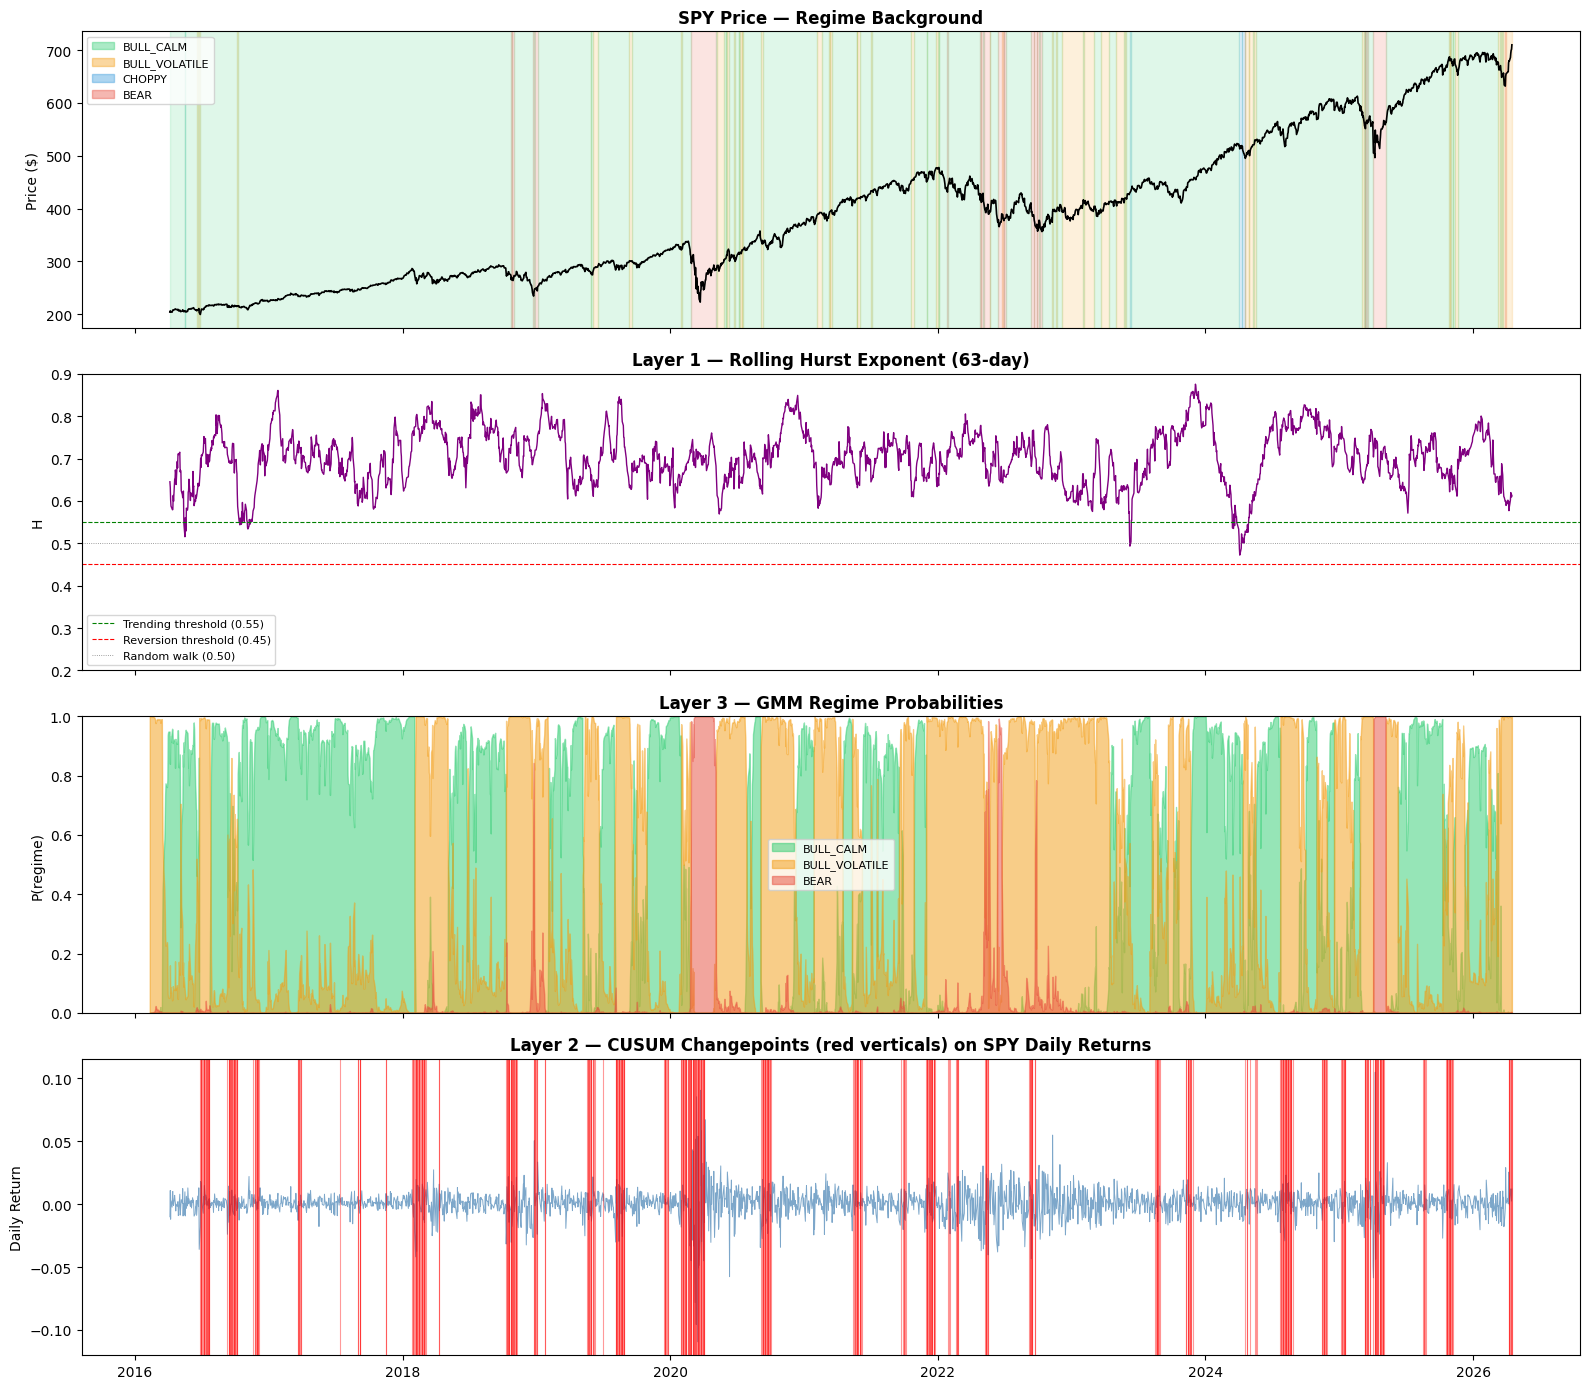

Chart saved → img/regime_analysis.png


In [6]:
REGIME_COLORS = {
    BULL_CALM:     "#2ecc71",   # green
    BULL_VOLATILE: "#f39c12",   # orange
    CHOPPY:        "#3498db",   # blue
    BEAR:          "#e74c3c",   # red
}

fig, axes = plt.subplots(4, 1, figsize=(16, 14), sharex=True)

spy_close = spy_df["close"].reindex(final_regime.index)

# Panel 1: SPY price with regime background shading
ax = axes[0]
ax.plot(spy_close.index, spy_close.values, color="black", lw=1.2, label="SPY Close")
prev_regime = None
start_date  = None
for date in final_regime.index:
    r = final_regime.loc[date]
    if r != prev_regime:
        if prev_regime is not None:
            ax.axvspan(start_date, date, alpha=0.15,
                       color=REGIME_COLORS.get(prev_regime, "grey"))
        prev_regime = r
        start_date  = date
if prev_regime:
    ax.axvspan(start_date, final_regime.index[-1], alpha=0.15,
               color=REGIME_COLORS.get(prev_regime, "grey"))
patches = [mpatches.Patch(color=c, alpha=0.4, label=r)
           for r, c in REGIME_COLORS.items()]
ax.legend(handles=patches, loc="upper left", fontsize=8)
ax.set_title("SPY Price — Regime Background", fontweight="bold")
ax.set_ylabel("Price ($)")

# Panel 2: Hurst exponent
ax = axes[1]
ax.plot(hurst_series.index, hurst_series.values, color="purple", lw=1.0)
ax.axhline(0.55, color="green",  ls="--", lw=0.8, label="Trending threshold (0.55)")
ax.axhline(0.45, color="red",    ls="--", lw=0.8, label="Reversion threshold (0.45)")
ax.axhline(0.50, color="grey",   ls=":",  lw=0.6, label="Random walk (0.50)")
ax.set_ylim(0.2, 0.9)
ax.set_title("Layer 1 — Rolling Hurst Exponent (63-day)", fontweight="bold")
ax.set_ylabel("H")
ax.legend(fontsize=8)

# Panel 3: GMM regime probabilities
ax = axes[2]
for regime, color in REGIME_COLORS.items():
    if regime in regime_probs.columns:
        ax.fill_between(regime_probs.index, regime_probs[regime],
                        alpha=0.5, label=regime, color=color)
ax.set_ylim(0, 1)
ax.set_title("Layer 3 — GMM Regime Probabilities", fontweight="bold")
ax.set_ylabel("P(regime)")
ax.legend(fontsize=8)

# Panel 4: CUSUM changepoints on SPY returns
ax = axes[3]
ax.plot(spy_returns.reindex(final_regime.index).index,
        spy_returns.reindex(final_regime.index).values,
        color="steelblue", lw=0.7, alpha=0.7)
for d in changepoint_dates:
    if d in final_regime.index:
        ax.axvline(d, color="red", alpha=0.4, lw=0.8)
ax.set_title("Layer 2 — CUSUM Changepoints (red verticals) on SPY Daily Returns",
             fontweight="bold")
ax.set_ylabel("Daily Return")

plt.tight_layout()
plt.savefig(STRATEGY_DIR / "img" / "regime_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved → img/regime_analysis.png")


## 4  Build Per-Symbol Feature Frames

In [7]:
from kernel.indicators import compute_all as _compute_all_ind

INDICATOR_SPEC = CONFIG["indicator_spec"]
MODEL_PARAMS   = CONFIG["model_params"]
FEATURE_COLS   = MODEL_PARAMS["feature_columns"]
LOOKAHEAD      = MODEL_PARAMS["lookahead"]     # 5 days
THRESHOLD      = MODEL_PARAMS["threshold"]     # 0.03 = 3%

spy_ind = _compute_all_ind(ohlcv["SPY"], INDICATOR_SPEC)

# Precompute rolling SPY regime context — training needs per-bar values, not just latest bar
spy_rets_all  = ohlcv["SPY"]["close"].pct_change()
spy_adx_all   = spy_ind["adx"] if spy_ind is not None and "adx" in spy_ind.columns else pd.Series(25.0, index=ohlcv["SPY"].index)
spy_ema50_all = ohlcv["SPY"]["close"].ewm(span=50, adjust=False).mean()
spy_trend_all = ohlcv["SPY"]["close"] / spy_ema50_all

feature_frames = {}
ratio_features = {"rsi", "adx"}
diff_features  = {"macd_hist", "cci", "bbp", "williams_r", "obv_slope"}

for ticker in WATCHLIST:
    if ticker not in ohlcv:
        print(f"  {ticker}: no data, skipping")
        continue
    try:
        stock_ind  = _compute_all_ind(ohlcv[ticker], INDICATOR_SPEC)
        if stock_ind is None or spy_ind is None:
            print(f"  {ticker}: indicator build returned None, skipping")
            continue
        common_idx = stock_ind.index.intersection(spy_ind.index)

        s = stock_ind.loc[common_idx].copy()
        p = spy_ind.loc[common_idx].copy()

        result = pd.DataFrame(index=common_idx)

        # Relative close: stock / SPY * 100 — labels measure outperformance vs SPY.
        # This prevents bull-market always-buy bias (raw returns are nearly always positive).
        spy_close_aligned = ohlcv["SPY"]["close"].reindex(common_idx)
        result["close"] = s["close"] / spy_close_aligned.replace(0, np.nan) * 100

        for col in ratio_features:
            if col in s.columns and col in p.columns:
                result[col] = s[col] / p[col].replace(0, np.nan)
        for col in diff_features:
            if col in s.columns and col in p.columns:
                result[col] = s[col] - p[col]

        # Trend features
        close  = s["close"]
        ema50  = close.ewm(span=50, adjust=False).mean()
        ema200 = close.ewm(span=200, adjust=False).mean()
        result["trend"]      = close / ema50
        result["trend_long"] = close / ema200
        spy_close_c = p["close"]
        rel_price   = close / spy_close_c
        result["rel_mom_20d"] = rel_price.pct_change(20)
        result["rel_mom_60d"] = rel_price.pct_change(60)

        # Regime context — rolling per-bar values for training accuracy
        spy_rets_c = spy_rets_all.reindex(common_idx)
        result["spy_realized_vol"] = spy_rets_c.rolling(20).std() * np.sqrt(252)
        result["spy_adx"]          = spy_adx_all.reindex(common_idx)
        result["spy_trend"]        = spy_trend_all.reindex(common_idx)
        result["hurst_proxy"]      = spy_rets_c.rolling(20).apply(
            lambda x: np.corrcoef(x[:-1], x[1:])[0, 1] if len(x) > 2 else 0.0, raw=True)

        # Relative forward return: stock outperformance vs SPY over LOOKAHEAD days.
        # Label +1 = stock beats SPY by THRESHOLD, -1 = underperforms, 0 = neutral.
        stock_fwd = ohlcv[ticker]["close"].pct_change(LOOKAHEAD).shift(-LOOKAHEAD)
        spy_fwd   = ohlcv["SPY"]["close"].pct_change(LOOKAHEAD).shift(-LOOKAHEAD)
        rel_fwd   = stock_fwd - spy_fwd.reindex(stock_fwd.index)
        result["fwd_return"] = rel_fwd.reindex(common_idx)
        result["label"] = np.where(result["fwd_return"] >  THRESHOLD,  1,
                          np.where(result["fwd_return"] < -THRESHOLD, -1, 0))

        result = result.dropna()
        feature_frames[ticker] = result
        lv = result["label"].value_counts().to_dict()
        print(f"  {ticker}: {len(result)} rows  "
              f"buy={lv.get(1,0)}  sell={lv.get(-1,0)}  hold={lv.get(0,0)}")
    except Exception as e:
        print(f"  {ticker}: ERROR — {e}")

print(f"\nBuilt frames for {len(feature_frames)} / {len(WATCHLIST)} symbols.")

  TSLA: 2496 rows  buy=797  sell=714  hold=985
  AMZN: 2496 rows  buy=412  sell=335  hold=1749
  GOOG: 2496 rows  buy=303  sell=256  hold=1937


  MSFT: 2496 rows  buy=209  sell=160  hold=2127


  AMD: 2496 rows  buy=831  sell=676  hold=989
  NFLX: 2496 rows  buy=574  sell=478  hold=1444
  CRM: 2496 rows  buy=390  sell=431  hold=1675


  PLTR: 1302 rows  buy=454  sell=401  hold=447
  UBER: 1653 rows  buy=438  sell=447  hold=768


  NVDA: 2496 rows  buy=794  sell=498  hold=1204
  META: 2496 rows  buy=457  sell=397  hold=1642


...

  UNH: 2496 rows  buy=376  sell=346  hold=1774
  CAT: 2496 rows  buy=443  sell=326  hold=1727


  BA: 2496 rows  buy=505  sell=505  hold=1486
  XLE: 2496 rows  buy=374  sell=383  hold=1739


  XLF: 2496 rows  buy=101  sell=82  hold=2313
  LLY: 2496 rows  buy=463  sell=384  hold=1649


  GLD: 2496 rows  buy=311  sell=304  hold=1881
  TLT: 2496 rows  buy=258  sell=364  hold=1874


  XLV: 2496 rows  buy=83  sell=104  hold=2309
  XLU: 2496 rows  buy=201  sell=264  hold=2031

Built frames for 23 / 23 symbols.


## 5  Train Per-Symbol Models (3-approach tournament)

In [8]:
from common.models import create_model
from common.portfolio import portfolio_stats
from common.tax import compute_after_tax_pnl

TRAIN_SPLIT   = CONFIG["train_split"]
BUY_THR       = MODEL_PARAMS["buy_threshold"]
SELL_THR      = MODEL_PARAMS["sell_threshold"]
BAGS          = MODEL_PARAMS["bags"]
LEAF_SIZE     = MODEL_PARAMS["leaf_size"]
ST_RATE       = CONFIG["tax"]["short_term_rate"]
LT_RATE       = CONFIG["tax"]["long_term_rate"]
LT_THRESH     = CONFIG["tax"]["long_term_threshold_days"]
SHARPE_FLOOR  = float(CONFIG.get("sharpe_floor", 0.8))  # 1.0 in strategy_config

results = {}

def oos_sharpe(prices, signals, tax_st=ST_RATE, tax_lt=LT_RATE, lt_days=LT_THRESH):
    """Annualised Sharpe on OOS signals (direct return calculation)."""
    try:
        prices = prices.dropna()
        if len(prices) < 20:
            return 0.0
        sigs = signals.reindex(prices.index).ffill().fillna(0).clip(0, 1)
        daily_ret = prices.pct_change().fillna(0)
        strat_ret = daily_ret * sigs.shift(1).fillna(0)
        std = strat_ret.std()
        if std == 0:
            return 0.0
        return float(strat_ret.mean() / std * np.sqrt(252))
    except Exception as e:
        print(f"    oos_sharpe error: {e}")
        return -99

for ticker in WATCHLIST:
    if ticker not in feature_frames:
        print(f"{ticker}: no feature frame, skipping")
        continue
    df = feature_frames[ticker]
    # Fixed date cutoff: train on data before 2024-01-01, OOS is 2024-01-01+.
    TRAIN_CUTOFF = pd.Timestamp("2024-01-01")
    train_df = df[df.index < TRAIN_CUTOFF]
    oos_df   = df[df.index >= TRAIN_CUTOFF]
    if len(train_df) < 60 or len(oos_df) < 30:
        print(f"{ticker}: insufficient data (train={len(train_df)}, oos={len(oos_df)}), skipping")
        continue
    prices   = ohlcv[ticker]["close"].reindex(oos_df.index)
    spy_prices = ohlcv["SPY"]["close"].reindex(oos_df.index).replace(0, np.nan)

    best_sharpe = -99
    best_model  = None
    best_name   = None
    best_sigs   = None
    best_scores = None   # continuous raw score for the winning model (used for ranking)
    best_calibration = None

    # ── Approach 1: Classification (BagLearner / RTLearner) ──
    try:
        _clf_seed = abs(hash(ticker)) % (2**32)
        np.random.seed(_clf_seed)
        clf = create_model("classification", feature_columns=FEATURE_COLS,
                           lookahead=LOOKAHEAD, threshold=THRESHOLD,
                           leaf_size=LEAF_SIZE, bags=BAGS,
                           buy_threshold=BUY_THR, sell_threshold=SELL_THR)
        clf.train(train_df)
        raw_sigs = clf.predict_bulk(oos_df)
        sigs = raw_sigs.map({"buy": 1, "hold": 0, "sell": -1}).reindex(oos_df.index)
        sh   = oos_sharpe(prices, sigs)
        print(f"  {ticker} Classification OOS Sharpe: {sh:.3f}")
        if sh > best_sharpe:
            best_sharpe = sh
            best_model  = clf
            best_name   = "Classification"
            best_sigs   = sigs
            best_scores = clf.predict_score_bulk(oos_df)   # raw float scores before thresholding
    except Exception as e:
        print(f"  {ticker} Classification error: {e}")

    # ── Approach 2: Q-Learning ──
    try:
        import random as _random
        _seed = abs(hash(ticker)) % (2**32)
        _random.seed(_seed)
        np.random.seed(_seed)
        ql = create_model("qlearning", feature_columns=FEATURE_COLS[:5])
        ql.train(train_df)
        raw_sigs = ql.predict_bulk(oos_df)
        sigs = raw_sigs.map({"buy": 1, "hold": 0, "sell": -1}).reindex(oos_df.index)
        sh   = oos_sharpe(prices, sigs)
        print(f"  {ticker} QLearning    OOS Sharpe: {sh:.3f}")
        if sh > best_sharpe:
            best_sharpe = sh
            best_model  = ql
            best_name   = "QLearning"
            best_sigs   = sigs
            best_scores = ql.predict_score_bulk(oos_df)    # Q(buy) - Q(sell)
    except Exception as e:
        print(f"  {ticker} QLearning error: {e}")

    # ── Approach 3: Manual baseline ──
    try:
        manual = create_model("manual", buy_threshold=2, sell_threshold=-2)
        manual.train(train_df)
        raw_sigs = manual.predict_bulk(oos_df)
        sigs = raw_sigs.map({"buy": 1, "hold": 0, "sell": -1}).reindex(oos_df.index)
        sh   = oos_sharpe(prices, sigs)
        print(f"  {ticker} Manual       OOS Sharpe: {sh:.3f}")
        if sh > best_sharpe:
            best_sharpe = sh
            best_model  = manual
            best_name   = "Manual"
            best_sigs   = sigs
            best_scores = manual.predict_score_bulk(oos_df)   # raw vote count
    except Exception as e:
        print(f"  {ticker} Manual error: {e}")

    # ── Approach 4: XGBoost (gradient boosted trees) ──
    try:
        from common.models import XGBoostModel
        _xgb_seed = abs(hash(ticker)) % (2**32)
        np.random.seed(_xgb_seed)
        xgb = XGBoostModel(feature_columns=FEATURE_COLS,
                           lookahead=LOOKAHEAD, threshold=THRESHOLD,
                           buy_threshold=0.1, sell_threshold=0.1,
                           n_estimators=200, max_depth=4,
                           learning_rate=0.05, subsample=0.8,
                           colsample_bytree=0.8, min_child_weight=10)
        xgb.train(train_df)
        raw_sigs = xgb.predict_bulk(oos_df)
        sigs = raw_sigs.map({"buy": 1, "hold": 0, "sell": -1}).reindex(oos_df.index)
        sh   = oos_sharpe(prices, sigs)
        print(f"  {ticker} XGBoost      OOS Sharpe: {sh:.3f}")
        if sh > best_sharpe:
            best_sharpe = sh
            best_model  = xgb
            best_name   = "XGBoost"
            best_sigs   = sigs
            best_scores = xgb.predict_score(oos_df)        # P(buy) - P(sell) in [-1, 1]
    except Exception as e:
        print(f"  {ticker} XGBoost error: {e}")

    if best_scores is not None:
        best_scores = pd.Series(best_scores, index=oos_df.index, dtype=float)
    if best_model is not None and best_scores is not None:
        rel_prices = (prices / spy_prices).replace([np.inf, -np.inf], np.nan)
        future_rel_returns = rel_prices.shift(-LOOKAHEAD) / rel_prices - 1.0
        best_calibration = fit_probability_calibration(
            best_scores,
            future_rel_returns,
            lookahead=LOOKAHEAD,
            threshold=THRESHOLD,
            score_kind=raw_score_kind_for_model(best_model),
        )

    results[ticker] = {
        "sharpe":          best_sharpe,
        "best_approach":   best_name,
        "model":           best_model,
        "oos_signals":     best_sigs,
        "oos_raw_scores":  best_scores,   # continuous signal strength — used for ranking in simulation
        "score_calibration": best_calibration,
        "oos_prices":      prices,
        "train_rows":      len(train_df),
        "oos_rows":        len(oos_df),
        "passes_floor":    best_sharpe >= SHARPE_FLOOR,
    }
    status = "✓ PASS" if best_sharpe >= SHARPE_FLOOR else "✗ FAIL (no model exported)"
    print(f"  → WINNER: {best_name}  Sharpe={best_sharpe:.3f}  {status}\n")

  TSLA Classification OOS Sharpe: 0.856


  TSLA QLearning    OOS Sharpe: 0.785
  TSLA Manual       OOS Sharpe: 0.343


  TSLA XGBoost      OOS Sharpe: 1.029
  → WINNER: XGBoost  Sharpe=1.029  ✓ PASS

  AMZN Classification OOS Sharpe: 0.448


  AMZN QLearning    OOS Sharpe: 0.947
  AMZN Manual       OOS Sharpe: 0.495


  AMZN XGBoost      OOS Sharpe: 1.181
  → WINNER: XGBoost  Sharpe=1.181  ✓ PASS

  GOOG Classification OOS Sharpe: -0.022


...

  TLT XGBoost      OOS Sharpe: -0.037
  → WINNER: Classification  Sharpe=0.747  ✗ FAIL (no model exported)

  XLV Classification OOS Sharpe: 0.000


  XLV QLearning    OOS Sharpe: 0.284
  XLV Manual       OOS Sharpe: -0.548


  XLV XGBoost      OOS Sharpe: -0.115
  → WINNER: QLearning  Sharpe=0.284  ✗ FAIL (no model exported)

  XLU Classification OOS Sharpe: -0.665


  XLU QLearning    OOS Sharpe: 1.239
  XLU Manual       OOS Sharpe: 0.736


  XLU XGBoost      OOS Sharpe: 1.484
  → WINNER: XGBoost  Sharpe=1.484  ✓ PASS



## 6  Export Models to LEAN artifact directory

In [9]:
from datetime import date as today_date

TODAY = str(today_date.today())
exported, skipped_floor = [], []

for ticker, r in results.items():
    if not r["passes_floor"]:
        skipped_floor.append(ticker)
        continue
    sym_dir = STRATEGY_DIR / "models" / ticker
    sym_dir.mkdir(parents=True, exist_ok=True)
    r["model"].save(sym_dir, model_name=ticker)

    # Patch metadata with 103-specific fields
    meta_path = sym_dir / f"{ticker}-policy-metadata.json"
    if meta_path.exists():
        with meta_path.open() as f:
            meta = json.load(f)
        meta["trained_date"]   = TODAY
        meta["best_approach"]  = r["best_approach"]
        meta["sharpe"]         = round(r["sharpe"], 4)
        meta["lookahead"]      = LOOKAHEAD
        meta["strategy"]       = STRATEGY
        if r.get("score_calibration") is not None:
            meta["score_calibration"] = r["score_calibration"].to_dict()
        with meta_path.open("w") as f:
            json.dump(meta, f, indent=2)
    exported.append(ticker)

print(f"Exported : {sorted(exported)}")
print(f"Skipped (below Sharpe floor {SHARPE_FLOOR}): {sorted(skipped_floor)}")

# ── Live Model Refresh (expanding window) ──────────────────────────────────
# The simulation above used models trained on data before 2024-01-01 (no look-ahead).
# For live trading we want models trained on ALL available data up to today,
# so the model has seen recent market patterns (tariff shocks, rate changes, etc).
# This second pass overwrites the exported artifacts with fresh expanding-window models.

print(f"\n=== Live model refresh: expanding window up to {TODAY} ===")
for ticker in exported:
    if ticker not in feature_frames:
        continue
    # Last 4 years only — recent data is most informative for live trading;
    # using all data since 2016 adds stale patterns that hurt more than help.
    LIVE_TRAIN_YEARS = 4
    cutoff_4yr = pd.Timestamp(TODAY) - pd.DateOffset(years=LIVE_TRAIN_YEARS)
    df_full = feature_frames[ticker][feature_frames[ticker].index >= cutoff_4yr]
    if len(df_full) < 60:
        df_full = feature_frames[ticker]   # fallback: use all data if 4yr window too short
    best_approach = results[ticker]["best_approach"]
    sym_dir = STRATEGY_DIR / "models" / ticker

    try:
        _seed = abs(hash(ticker)) % (2**32)
        np.random.seed(_seed)

        if best_approach == "Classification":
            live_model = create_model("classification", feature_columns=FEATURE_COLS,
                                      lookahead=LOOKAHEAD, threshold=THRESHOLD,
                                      leaf_size=LEAF_SIZE, bags=BAGS,
                                      buy_threshold=BUY_THR, sell_threshold=SELL_THR)
            live_model.train(df_full)

        elif best_approach == "QLearning":
            import random as _random
            _random.seed(_seed)
            live_model = create_model("qlearning", feature_columns=FEATURE_COLS[:5])
            live_model.train(df_full)

        elif best_approach == "XGBoost":
            from common.models import XGBoostModel
            live_model = XGBoostModel(feature_columns=FEATURE_COLS,
                                      lookahead=LOOKAHEAD, threshold=THRESHOLD,
                                      buy_threshold=0.1, sell_threshold=0.1,
                                      n_estimators=200, max_depth=4,
                                      learning_rate=0.05, subsample=0.8,
                                      colsample_bytree=0.8, min_child_weight=10)
            live_model.train(df_full)

        elif best_approach == "Manual":
            live_model = create_model("manual", buy_threshold=2, sell_threshold=-2)
            live_model.train(df_full)

        else:
            print(f"  {ticker}: unknown approach {best_approach!r}, skipping")
            continue

        live_model.save(sym_dir, model_name=ticker)

        # Patch metadata: live_model.save() creates bare metadata — re-apply all fields.
        # Sharpe and best_approach come from the fixed-cutoff backtest evaluation.
        meta_path = sym_dir / f"{ticker}-policy-metadata.json"
        if meta_path.exists():
            with meta_path.open() as f:
                meta = json.load(f)
            meta["trained_date"]    = TODAY
            meta["best_approach"]   = best_approach
            meta["sharpe"]          = round(results[ticker]["sharpe"], 4)
            meta["lookahead"]       = LOOKAHEAD
            meta["strategy"]        = STRATEGY
            meta["live_train_rows"] = len(df_full)
            meta["live_train_end"]  = str(df_full.index[-1].date())
            if results[ticker].get("score_calibration") is not None:
                meta["score_calibration"] = results[ticker]["score_calibration"].to_dict()
            with meta_path.open("w") as f:
                json.dump(meta, f, indent=2)

        print(f"  {ticker}: {best_approach}, {len(df_full)} rows, "
              f"train_end={df_full.index[-1].date()}")

    except Exception as e:
        print(f"  {ticker}: refresh FAILED — {e}")

print("Live model refresh complete.")


Exported : ['AAPL', 'AMD', 'AMZN', 'CAT', 'GLD', 'GOOG', 'JPM', 'LLY', 'META', 'NVDA', 'PLTR', 'TSLA', 'XLF', 'XLU']
Skipped (below Sharpe floor 1.0): ['BA', 'CRM', 'MSFT', 'NFLX', 'TLT', 'UBER', 'UNH', 'XLE', 'XLV']

=== Live model refresh: expanding window up to 2026-04-19 ===


  TSLA: XGBoost, 998 rows, train_end=2026-04-10


  AMZN: XGBoost, 998 rows, train_end=2026-04-10


  GOOG: QLearning, 998 rows, train_end=2026-04-10
  AMD: Classification, 998 rows, train_end=2026-04-10


  PLTR: XGBoost, 998 rows, train_end=2026-04-10
  NVDA: Manual, 998 rows, train_end=2026-04-10
  META: Manual, 998 rows, train_end=2026-04-10
  AAPL: Manual, 998 rows, train_end=2026-04-10


  JPM: XGBoost, 998 rows, train_end=2026-04-10
  CAT: Classification, 998 rows, train_end=2026-04-10
  XLF: Manual, 998 rows, train_end=2026-04-10


  LLY: XGBoost, 998 rows, train_end=2026-04-10


  GLD: QLearning, 998 rows, train_end=2026-04-10


  XLU: XGBoost, 998 rows, train_end=2026-04-10
Live model refresh complete.


## 7  Correlation Matrix — Watchlist Diversification

Correlation matrix saved → /Users/renhao/git/github/RenQuant/backtesting/renquant_103/artifacts/watchlist-correlation.json


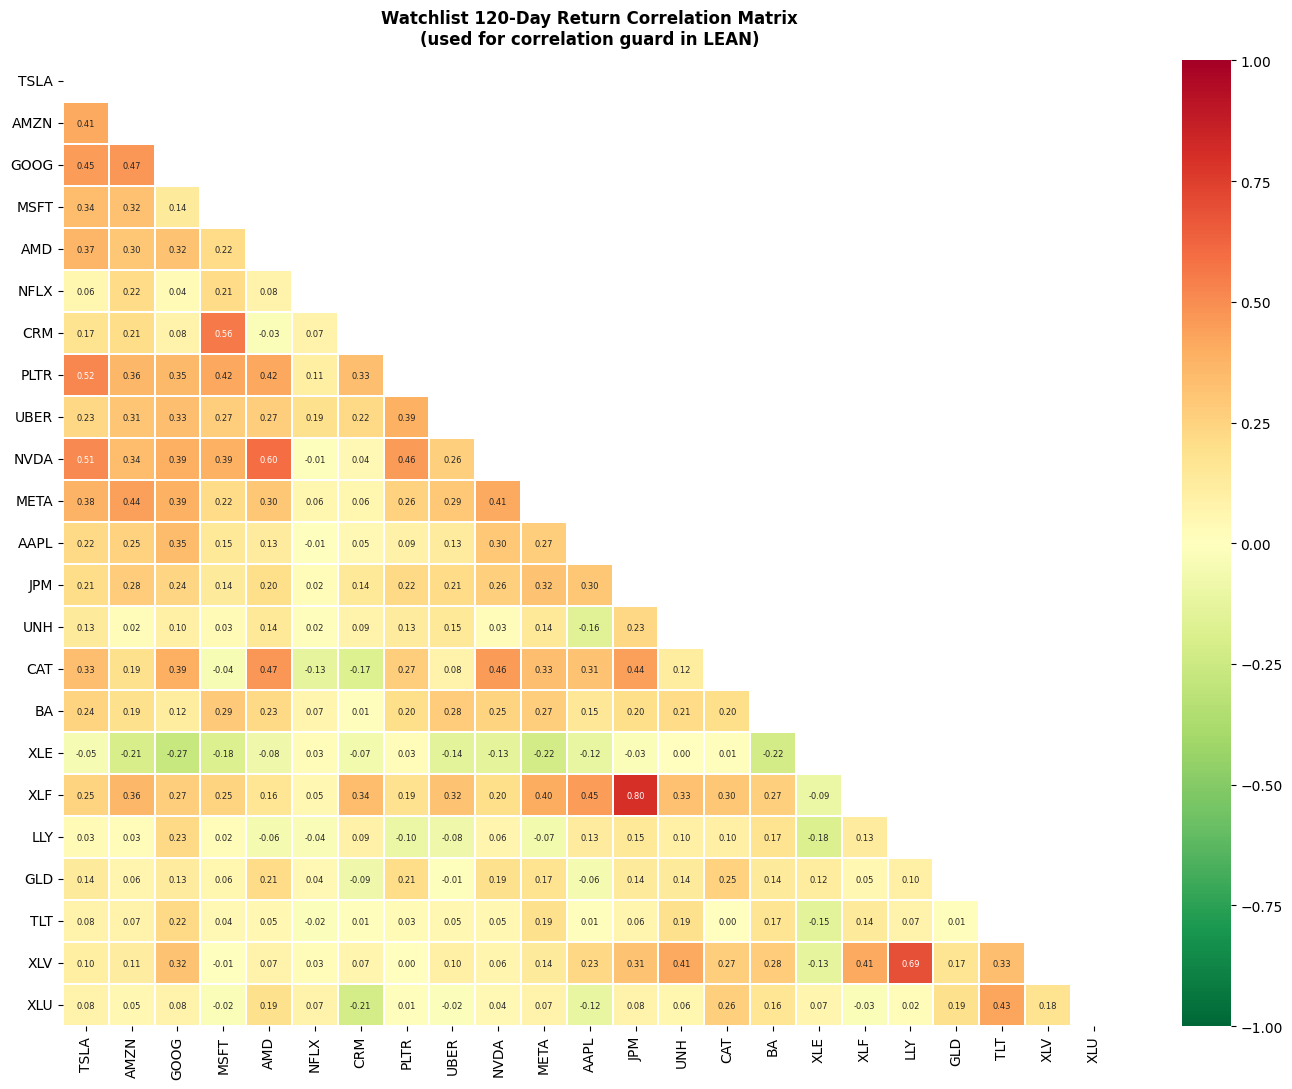

Heatmap saved → img/correlation_heatmap.png


In [10]:
# Compute 60-day rolling correlation on OOS period (use full sample for the artifact)
close_df = pd.DataFrame({
    t: ohlcv[t]["close"] for t in WATCHLIST if t in ohlcv
})
ret_df = close_df.pct_change().dropna()

# Use last 120 days for the artifact (representative of current correlations)
corr_matrix = ret_df.tail(120).corr()

# Save as JSON for LEAN — artifacts/ subdir (DataJob checks there first)
corr_dict = {}
for ticker in corr_matrix.index:
    corr_dict[ticker] = {
        other: round(float(corr_matrix.loc[ticker, other]), 4)
        for other in corr_matrix.columns
    }
artifacts_dir = STRATEGY_DIR / "artifacts"
artifacts_dir.mkdir(exist_ok=True)
corr_path = artifacts_dir / "watchlist-correlation.json"
corr_path.write_text(json.dumps(corr_dict, indent=2))
print(f"Correlation matrix saved → {corr_path}")

# Plot heatmap
fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="RdYlGn_r",
            center=0, vmin=-1, vmax=1, linewidths=0.3, ax=ax,
            annot_kws={"size": 6})
ax.set_title("Watchlist 120-Day Return Correlation Matrix\n(used for correlation guard in LEAN)",
             fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig(STRATEGY_DIR / "img" / "correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Heatmap saved → img/correlation_heatmap.png")

## 8  Model Summary Table

            Sector Defensive        Approach OOS Sharpe Exported  OOS rows
Ticker                                                                    
TSLA          tech                   XGBoost      1.029        ✓       570
AMZN          tech                   XGBoost      1.181        ✓       570
GOOG          tech                 QLearning      1.068        ✓       570
MSFT          tech                 QLearning      0.335        ✗       570
AMD           tech            Classification      1.333        ✓       570
NFLX          tech                 QLearning      0.998        ✗       570
CRM           tech                    Manual     -0.279        ✗       570
PLTR          tech                   XGBoost      2.080        ✓       570
UBER          tech                   XGBoost      0.295        ✗       570
NVDA          tech                    Manual      1.920        ✓       570
META          tech                    Manual      1.081        ✓       570
AAPL          tech       

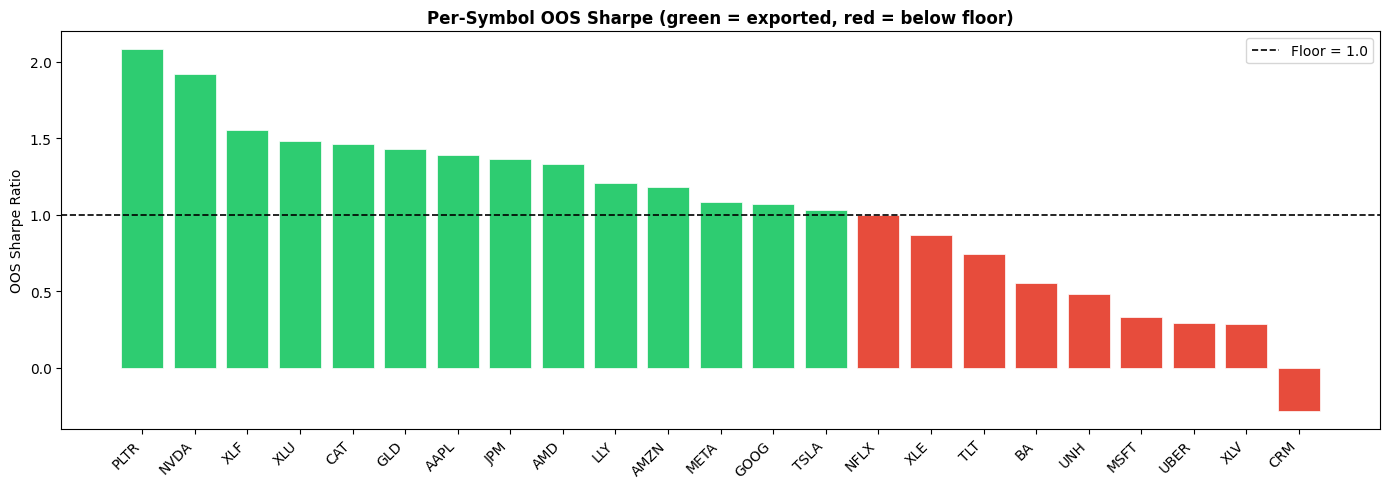

In [11]:
summary_rows = []
for ticker in WATCHLIST:
    r = results.get(ticker, {})
    summary_rows.append({
        "Ticker":    ticker,
        "Sector":    CONFIG["sector_map"].get(ticker, "?"),
        "Defensive": "✓" if ticker in DEFENSIVE else "",
        "Approach":  r.get("best_approach", "—"),
        "OOS Sharpe": f"{r['sharpe']:.3f}" if r.get("sharpe") else "—",
        "Exported":  "✓" if r.get("passes_floor") else "✗",
        "OOS rows":  r.get("oos_rows", 0),
    })

summary = pd.DataFrame(summary_rows).set_index("Ticker")
print(summary.to_string())

# Bar chart of OOS Sharpes
sharpe_vals = {k: v.get("sharpe", 0) for k, v in results.items()}
sharpe_s = pd.Series(sharpe_vals).sort_values(ascending=False)
colors = ["#2ecc71" if v >= SHARPE_FLOOR else "#e74c3c" for v in sharpe_s.values]

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(sharpe_s.index, sharpe_s.values, color=colors, edgecolor="white", linewidth=0.5)
ax.axhline(SHARPE_FLOOR, color="black", ls="--", lw=1.2, label=f"Floor = {SHARPE_FLOOR}")
ax.set_title("Per-Symbol OOS Sharpe (green = exported, red = below floor)",
             fontweight="bold")
ax.set_ylabel("OOS Sharpe Ratio")
ax.set_xticklabels(sharpe_s.index, rotation=45, ha="right")
ax.legend()
plt.tight_layout()
plt.savefig(STRATEGY_DIR / "img" / "model_sharpe_summary.png", dpi=150, bbox_inches="tight")
plt.show()


## 9  Portfolio Simulation (mirrors LEAN regime-aware logic)

In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# Portfolio Simulation — kernel-based, streaming regime detection.
# Mirrors LEAN: all 5 exits in priority order, market gates, tiered selection,
# confidence-scaled sizing, wash-sale, tax, BEAR defensive rotation.
# ─────────────────────────────────────────────────────────────────────────────
import sys as _sys, json as _json
from collections import Counter

from kernel.exits        import HoldingState, compute_exits
from kernel.regime       import detect_regime, RegimeState, load_gmm_artifact
from kernel.sizing       import compute_position_size
from kernel.selection    import (CandidateResult, SelectionContext,
                                 score_candidates, run_selection_loop,
                                 compute_relative_strength)
from kernel.portfolio    import update_drawdown_circuit_breaker, compute_trade_tax
from kernel.market_gates import check_spy_velocity_crash, check_spy_ema_trend

# ── Config ────────────────────────────────────────────────────────────────────
BACKTEST_START    = CONFIG["backtest_start"]
BACKTEST_END      = CONFIG["backtest_end"]
INITIAL_CASH      = CONFIG["initial_cash"]
MAX_POSITIONS     = CONFIG["max_concurrent_positions"]
CORR_THRESHOLD    = CONFIG["regime"]["correlation_guard_threshold"]
WASH_SALE_DAYS    = CONFIG.get("wash_sale_days", 30)
MIN_HOLD_DAYS     = CONFIG.get("min_hold_days", 30)   # model-sell blocked before N days
CONSECUTIVE_SELLS = CONFIG.get("consecutive_sell_signals", 3)
TIERED_THRESHOLDS = CONFIG.get("tiered_thresholds", [{"min_model_score": 0.10}])
MAX_PER_SECTOR    = CONFIG.get("max_positions_per_sector", 3)
EARNINGS_BUFFER   = CONFIG["regime"].get("earnings_buffer_days", 3)
DEFENSIVE_TICKERS = set(CONFIG.get("defensive_tickers", []))
BEAR_DEFENSIVE_PCT, BEAR_DEFENSIVE_SLOTS = 0.15, 1
LT_HOLD_GATE_DAYS = CONFIG.get("lt_hold_gate_days", 330)
LT_HOLD_MIN_GAIN  = CONFIG.get("lt_hold_min_gain", 0.10)

ST_RATE   = CONFIG["tax"]["short_term_rate"]
LT_RATE   = CONFIG["tax"]["long_term_rate"]
LT_THRESH = CONFIG["tax"]["long_term_threshold_days"]

RP = CONFIG["regime_params"]
bc = RP["BULL_CALM"]
SPY_VEL_HALT_PCT      = bc.get("spy_velocity_halt_pct", 0.03)
SPY_VEL_LOOKBACK_DAYS = int(bc.get("spy_velocity_lookback_days", 3))

BW = CONFIG.get("ranking", {}).get("blend_weights", [0.5, 0.5])
_bt = float(BW[0]) + float(BW[1]) or 1.0
RANK_W, RS_W = float(BW[0]) / _bt, float(BW[1]) / _bt

# Load artifacts from artifacts/ subdir
_artifacts_dir = STRATEGY_DIR / "artifacts"
if not _artifacts_dir.exists():
    _artifacts_dir = STRATEGY_DIR   # fallback

_ep = _artifacts_dir / CONFIG["regime"].get("earnings_artifact", "earnings-calendar.json")
_earnings_cal = _json.loads(_ep.read_text()) if _ep.exists() else {}

_gmm_path = _artifacts_dir / CONFIG["regime"].get("gmm_artifact", "spy-gmm-regime.json")
_gmm_artifact = load_gmm_artifact(_gmm_path)
print(f"GMM artifact loaded: {_gmm_artifact is not None}")
print(f"Earnings calendar entries: {sum(len(v) for v in _earnings_cal.values())}")

# ── Small helpers ─────────────────────────────────────────────────────────────
def _is_earnings_blocked(ticker, today_ts):
    for d in _earnings_cal.get(ticker, []):
        try:
            if abs((pd.Timestamp(d).date() - today_ts.date()).days) <= EARNINGS_BUFFER:
                return True
        except Exception:
            pass
    return False

def _rank_score(ticker, today_ts):
    raw = results[ticker].get("oos_raw_scores")
    if raw is None or today_ts not in raw.index:
        return None
    cal = results[ticker].get("score_calibration")
    return float(cal.calibrate(float(raw.loc[today_ts]))) if cal else float(raw.loc[today_ts])

def _action(ticker, today_ts):
    sigs = results[ticker].get("oos_signals")
    if sigs is None or today_ts not in sigs.index:
        return "hold"
    v = sigs.loc[today_ts]
    return "buy" if v == 1 else ("sell" if v == -1 else "hold")

# ── State ─────────────────────────────────────────────────────────────────────
cash                                     = float(INITIAL_CASH)
hwm                                      = float(INITIAL_CASH)
skip_buys                                = False
holdings: dict[str, HoldingState]       = {}
pos_shares: dict[str, float]            = {}   # shares per position
last_sell_date: dict[str, pd.Timestamp] = {}
equity_curve, trade_log                 = [], []
exportable      = {t for t, r in results.items() if r.get("passes_floor")}

# Streaming regime state — persists CUSUM countdown across bars
regime_state = RegimeState()

bt_dates      = spy_df.loc[BACKTEST_START:BACKTEST_END].index
spy_daily_ret = spy_df["close"].pct_change().fillna(0)

# ── Main loop ─────────────────────────────────────────────────────────────────
for bar_i, today in enumerate(bt_dates):
    # ── Streaming regime detection (Hurst + CUSUM + GMM) ──────────────────────
    spy_rets_arr  = spy_daily_ret.loc[:today].values.astype(float)
    spy_df_window = spy_df.loc[:today]
    regime_state  = detect_regime(spy_rets_arr, spy_df_window, _gmm_artifact,
                                  regime_state, CONFIG)
    regime        = regime_state.regime
    regime_conf   = regime_state.confidence
    in_transition = regime_state.in_transition

    rp = RP.get(regime, RP["BULL_CALM"])

    # Mark-to-market
    port_val = cash + sum(
        pos_shares[t] * float(ohlcv[t].loc[today, "close"])
        for t in holdings if t in ohlcv and today in ohlcv[t].index
    )

    # Drawdown circuit breaker
    hwm, skip_buys = update_drawdown_circuit_breaker(
        port_val, hwm, float(rp["drawdown_halt_pct"]))
    equity_curve.append({"date": today, "portfolio": port_val, "regime": regime})

    # ── SELLS ─────────────────────────────────────────────────────────────────
    exit_params = {
        "trailing_stop_trigger_pct": rp.get("trailing_stop_trigger_pct", 0),
        "trailing_stop_trail_pct":   rp.get("trailing_stop_trail_pct", 0),
        "stop_loss_pct":             rp["stop_loss_pct"],
        "max_single_day_loss_pct":   rp.get("max_single_day_loss_pct", 0),
        "max_hold_days":             rp["max_hold_days"],
        "consecutive_sell_signals":  CONSECUTIVE_SELLS,
        "min_hold_days":             MIN_HOLD_DAYS,
        "lt_hold_gate_days":         LT_HOLD_GATE_DAYS,
        "lt_hold_min_gain":          LT_HOLD_MIN_GAIN,
    }
    to_sell = []
    for t, st in list(holdings.items()):
        if today not in ohlcv.get(t, pd.DataFrame()).index:
            continue
        price = float(ohlcv[t].loc[today, "close"])
        sig, updated = compute_exits(price, today.date(), _action(t, today), st, exit_params)
        updated.prev_close = price
        holdings[t] = updated
        if sig.should_exit:
            to_sell.append((t, price, sig.exit_type))

    for t, price, reason in to_sell:
        st        = holdings.pop(t)
        shares    = pos_shares.pop(t)
        hold_days = (today.date() - st.entry_date).days
        gross_pnl = shares * (price - st.entry_price)
        tax       = compute_trade_tax(gross_pnl, hold_days, ST_RATE, LT_RATE, LT_THRESH)
        cash     += shares * price - tax
        last_sell_date[t] = today
        trade_log.append({"action": "sell", "ticker": t, "date": today,
                          "pnl_pct": (price - st.entry_price) / st.entry_price,
                          "hold_days": hold_days, "tax": tax, "exit_reason": reason})

    # ── Transition uncertainty window — no new buys ────────────────────────────
    if in_transition:
        continue

    # ── BEAR branch: defensives only ──────────────────────────────────────────
    if regime == "BEAR":
        defensive_held = sum(1 for t in holdings if t in DEFENSIVE_TICKERS)
        if not skip_buys and defensive_held < BEAR_DEFENSIVE_SLOTS:
            def_sorted = sorted(
                (t for t in exportable & DEFENSIVE_TICKERS
                 if t not in holdings
                 and today in ohlcv.get(t, pd.DataFrame()).index
                 and _action(t, today) == "buy"
                 and (not last_sell_date.get(t) or
                      (today - last_sell_date[t]).days >= WASH_SALE_DAYS)
                 and _rank_score(t, today) is not None),
                key=lambda x: _rank_score(x, today), reverse=True,
            )
            for t in def_sorted:
                price = float(ohlcv[t].loc[today, "close"])
                _, shares = compute_position_size(
                    port_val, cash, 0, 0, price, override_pct=BEAR_DEFENSIVE_PCT)
                if shares < 1:
                    continue
                invest = shares * price
                cash  -= invest
                holdings[t]  = HoldingState(entry_price=price, entry_date=today.date(),
                                            high_watermark=price, prev_close=price)
                pos_shares[t] = shares
                trade_log.append({"action": "buy", "ticker": t, "date": today,
                                  "price": price, "shares": shares, "invest": invest,
                                  "regime": "BEAR_defensive"})
                break
        continue

    # ── Market gates ──────────────────────────────────────────────────────────
    spy_rets_window = list(spy_daily_ret.loc[:today].values)
    spy_close_hist  = spy_df["close"].loc[:today]
    if (skip_buys
            or len(holdings) >= MAX_POSITIONS
            or check_spy_velocity_crash(spy_rets_window, SPY_VEL_LOOKBACK_DAYS, SPY_VEL_HALT_PCT)
            or check_spy_ema_trend(spy_close_hist, ema_span=50)):
        continue

    # ── Candidate scan ────────────────────────────────────────────────────────
    open_slots   = MAX_POSITIONS - len(holdings)
    max_pos_pct  = float(rp.get("max_position_pct", 0.15)) * regime_conf
    cash_res_pct = float(rp.get("cash_reserve_pct", 0.0)) * regime_conf
    min_score    = float(rp.get("min_model_score", 0.10))

    candidates = []
    for t in exportable:
        if (t in holdings
                or today not in ohlcv.get(t, pd.DataFrame()).index
                or _action(t, today) != "buy"):
            continue
        last_s = last_sell_date.get(t)
        if last_s is not None and (today - last_s).days < WASH_SALE_DAYS:
            continue
        if _is_earnings_blocked(t, today):
            continue
        rs = _rank_score(t, today)
        if rs is None or rs < min_score:
            continue
        sector = CONFIG["sector_map"].get(t, "other")
        etf    = SECTOR_ETF.get(sector)
        rs_sc  = 0.0
        if etf and etf in ohlcv and today in ohlcv[etf].index:
            try:
                rs_sc = compute_relative_strength(
                    float(ohlcv[t]["close"].pct_change(20).loc[today]),
                    float(ohlcv[etf]["close"].pct_change(20).loc[today]),
                )
            except Exception:
                pass
        candidates.append(CandidateResult(ticker=t, raw_score=rs, rank_score=rs, rs_score=rs_sc))

    if not candidates:
        continue

    # ── Rank & select ─────────────────────────────────────────────────────────
    ranked = score_candidates(candidates, RANK_W, RS_W)
    ctx = SelectionContext(
        today=today.date(),
        held_tickers=list(holdings.keys()),
        last_sell_dates={t: d.date() for t, d in last_sell_date.items()},
        earnings_calendar=_earnings_cal,
        corr_matrix=corr_dict,
        sector_map=CONFIG["sector_map"],
        defensive_set=DEFENSIVE_TICKERS,
        wash_sale_days=WASH_SALE_DAYS,
        earnings_buffer=EARNINGS_BUFFER,
        corr_threshold=CORR_THRESHOLD,
        max_per_sector=MAX_PER_SECTOR,
        tiered_thresholds=TIERED_THRESHOLDS,
        open_slots=open_slots,
    )
    selected, _ = run_selection_loop(ranked, ctx)

    for t in selected:
        price = float(ohlcv[t].loc[today, "close"])
        _, shares = compute_position_size(port_val, cash, max_pos_pct, cash_res_pct, price)
        if shares < 1:
            continue
        invest = shares * price
        cash  -= invest
        holdings[t]   = HoldingState(entry_price=price, entry_date=today.date(),
                                     high_watermark=price, prev_close=price)
        pos_shares[t] = shares
        trade_log.append({"action": "buy", "ticker": t, "date": today,
                          "price": price, "shares": shares, "invest": invest})

# ── Summary ───────────────────────────────────────────────────────────────────
equity_df = pd.DataFrame(equity_curve).set_index("date")
final_val = equity_df["portfolio"].iloc[-1]
total_ret = final_val / INITIAL_CASH - 1
n_years   = len(equity_df) / 252
apy       = (1 + total_ret) ** (1 / n_years) - 1 if n_years > 0 else 0

buys  = [t for t in trade_log if t["action"] == "buy"]
sells = [t for t in trade_log if t["action"] == "sell"]
wins  = [t for t in sells if t["pnl_pct"] > 0]
print(f"Simulation complete: {len(equity_df)} days")
print(f"Final value: ${final_val:,.0f}  |  Return: {total_ret:.1%}  |  APY: {apy:.1%}")
print(f"Trades: {len(buys)} buys, {len(sells)} sells  |  Win rate: {len(wins)/max(1,len(sells)):.0%}")
if sells:
    avg_hold  = sum(t["hold_days"] for t in sells) / len(sells)
    avg_pnl   = sum(t["pnl_pct"]  for t in sells) / len(sells)
    total_tax = sum(t["tax"]       for t in sells)
    reasons   = Counter(t.get("exit_reason", "?") for t in sells)
    print(f"Avg hold: {avg_hold:.0f}d  |  Avg P&L/trade: {avg_pnl:.1%}  |  Total tax: ${total_tax:,.0f}")
    print(f"Exit reasons: {dict(reasons)}")

GMM artifact loaded: True
Earnings calendar entries: 21


Simulation complete: 560 days
Final value: $140,170  |  Return: 40.2%  |  APY: 16.4%
Trades: 66 buys, 63 sells  |  Win rate: 67%
Avg hold: 59d  |  Avg P&L/trade: 8.6%  |  Total tax: $60,061
Exit reasons: {'model_sell': 35, 'max_hold': 7, 'stop_loss': 12, 'single_day_loss': 6, 'trailing_stop': 3}


## 10  Portfolio Performance Charts

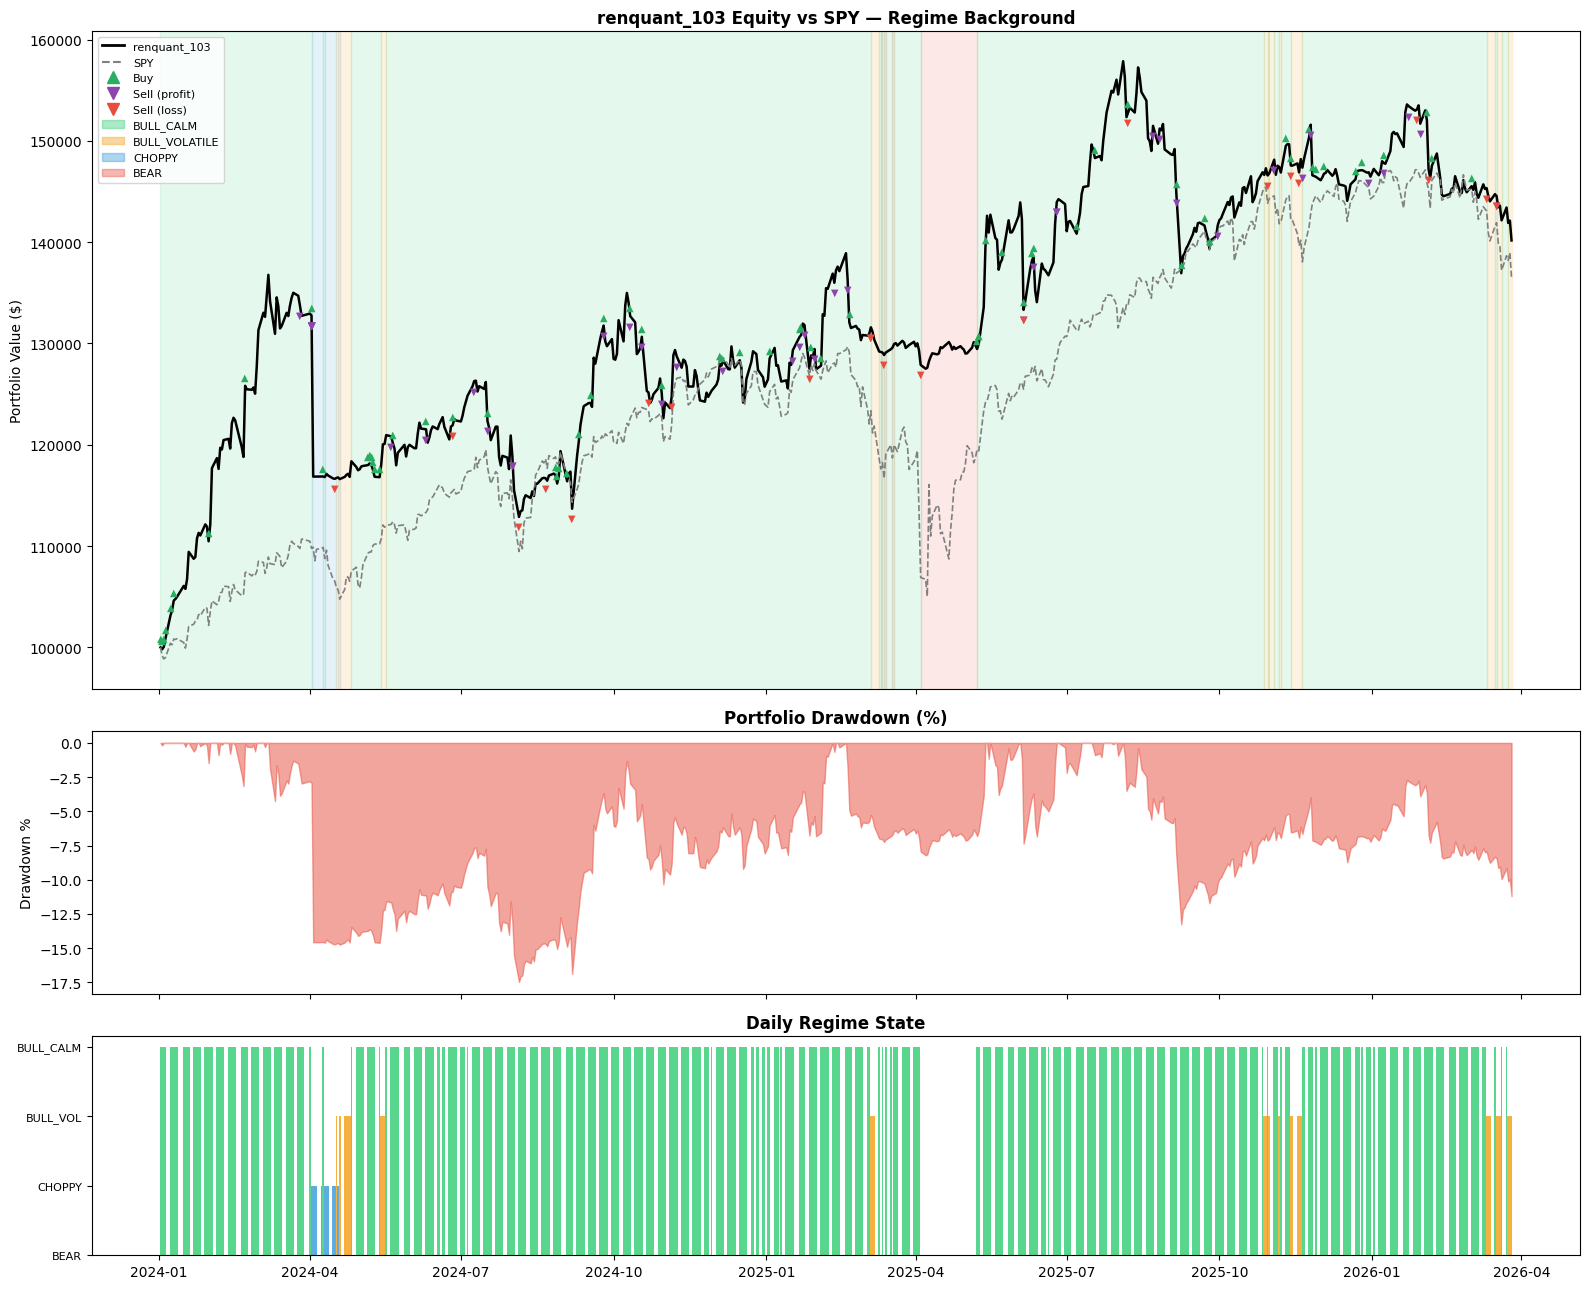

In [13]:
# SPY benchmark
spy_bt = spy_df["close"].loc[BACKTEST_START:BACKTEST_END]
spy_norm = spy_bt / spy_bt.iloc[0] * INITIAL_CASH

fig, axes = plt.subplots(3, 1, figsize=(16, 13), sharex=True,
                         gridspec_kw={"height_ratios": [3, 1.2, 1]})

# ── Panel 1: Equity curve with regime background ──
ax = axes[0]
port_norm = equity_df["portfolio"]

# Shade by regime
prev_r = None; start_d = None
for d in equity_df.index:
    r = equity_df.loc[d, "regime"]
    if r != prev_r:
        if prev_r:
            ax.axvspan(start_d, d, alpha=0.12, color=REGIME_COLORS.get(prev_r, "grey"))
        prev_r  = r; start_d = d
if prev_r:
    ax.axvspan(start_d, equity_df.index[-1], alpha=0.12, color=REGIME_COLORS.get(prev_r, "grey"))

ax.plot(port_norm.index, port_norm.values, color="black", lw=1.8, label="renquant_103")
ax.plot(spy_norm.index,  spy_norm.values,  color="grey",  lw=1.2, ls="--", label="SPY")

# ── Buy/sell markers ──
buy_trades  = [t for t in trade_log if t["action"] == "buy"  and t["date"] in port_norm.index]
sell_trades = [t for t in trade_log if t["action"] == "sell" and t["date"] in port_norm.index]
for t in buy_trades:
    ax.annotate("▲", xy=(t["date"], port_norm.loc[t["date"]]),
                fontsize=7, color="#27ae60", ha="center", va="bottom",
                xytext=(0, 3), textcoords="offset points")
for t in sell_trades:
    pnl = t.get("pnl_pct", 0)
    color = "#e74c3c" if pnl < 0 else "#8e44ad"
    ax.annotate("▼", xy=(t["date"], port_norm.loc[t["date"]]),
                fontsize=7, color=color, ha="center", va="top",
                xytext=(0, -3), textcoords="offset points")

patches = [mpatches.Patch(color=c, alpha=0.4, label=r) for r, c in REGIME_COLORS.items()]
ax.legend(handles=[
    plt.Line2D([0],[0],color="black",lw=2,label="renquant_103"),
    plt.Line2D([0],[0],color="grey",lw=1.5,ls="--",label="SPY"),
    plt.Line2D([0],[0],marker="^",color="#27ae60",lw=0,markersize=8,label="Buy"),
    plt.Line2D([0],[0],marker="v",color="#8e44ad",lw=0,markersize=8,label="Sell (profit)"),
    plt.Line2D([0],[0],marker="v",color="#e74c3c",lw=0,markersize=8,label="Sell (loss)"),
] + patches, fontsize=8)
ax.set_title("renquant_103 Equity vs SPY — Regime Background", fontweight="bold")
ax.set_ylabel("Portfolio Value ($)")

# ── Panel 2: Drawdown ──
ax = axes[1]
roll_max = port_norm.cummax()
drawdown = (port_norm - roll_max) / roll_max * 100
ax.fill_between(drawdown.index, drawdown.values, 0, color="#e74c3c", alpha=0.5)
ax.set_title("Portfolio Drawdown (%)", fontweight="bold")
ax.set_ylabel("Drawdown %")

# ── Panel 3: Regime state ──
ax = axes[2]
regime_numeric = {BULL_CALM: 3, BULL_VOLATILE: 2, CHOPPY: 1, BEAR: 0}
regime_vals    = equity_df["regime"].map(regime_numeric).fillna(-1)
colors_seq     = equity_df["regime"].map(REGIME_COLORS).fillna("grey")

ax.bar(regime_vals.index, regime_vals.values,
       color=colors_seq.values, width=1, alpha=0.8)
ax.set_yticks([0,1,2,3])
ax.set_yticklabels(["BEAR","CHOPPY","BULL_VOL","BULL_CALM"], fontsize=8)
ax.set_title("Daily Regime State", fontweight="bold")

plt.tight_layout()
plt.savefig(STRATEGY_DIR / "img" / "portfolio_simulation.png", dpi=150, bbox_inches="tight")
plt.show()


In [14]:
# ── Performance statistics ──

def calc_stats(series):
    """Compute standard performance metrics from an equity series."""
    series = series.dropna()
    daily_ret = series.pct_change().dropna()
    n_years = len(daily_ret) / 252
    total_return = series.iloc[-1] / series.iloc[0] - 1
    cagr = (1 + total_return) ** (1 / n_years) - 1 if n_years > 0 else 0
    sharpe = float(daily_ret.mean() / daily_ret.std() * np.sqrt(252)) if daily_ret.std() > 0 else 0
    roll_max = series.cummax()
    max_dd = float(((series - roll_max) / roll_max).min())
    volatility = float(daily_ret.std() * np.sqrt(252))
    return {"total_return": total_return, "cagr": cagr, "sharpe": sharpe,
            "max_drawdown": max_dd, "volatility": volatility}

stats     = calc_stats(equity_df["portfolio"])
spy_stats = calc_stats(spy_norm)

print("=" * 45)
print(f"{'Metric':<25} {'103':>8}  {'SPY':>8}")
print("=" * 45)
# Add APY to stats dict (same formula as CAGR but labeled for clarity)
stats["apy"]     = stats["cagr"]
spy_stats["apy"] = spy_stats["cagr"]

for k in ["total_return", "apy", "sharpe", "max_drawdown", "volatility"]:
    v103 = stats.get(k, 0)
    vspy = spy_stats.get(k, 0)
    if k in ("total_return", "apy", "max_drawdown", "volatility"):
        print(f"{k:<25} {v103:>7.1%}  {vspy:>7.1%}")
    else:
        print(f"{k:<25} {v103:>8.3f}  {vspy:>8.3f}")
print("=" * 45)

# Regime breakdown
print("\nRegime days:")
for r, c in REGIME_COLORS.items():
    n = (equity_df["regime"] == r).sum()
    pct = n / len(equity_df)
    print(f"  {r:<16} {n:>4}d  {pct:.1%}")

Metric                         103       SPY
total_return                40.2%    36.5%
apy                         16.4%    15.1%
sharpe                       0.861     0.952
max_drawdown               -17.5%   -19.0%
volatility                  20.1%    16.1%

Regime days:
  BULL_CALM         493d  88.0%
  BULL_VOLATILE      30d  5.4%
  CHOPPY             11d  2.0%
  BEAR               26d  4.6%


## 10b  Trade Log & Detailed Analysis

In [15]:
# ── All trades table ──
import pandas as pd

if trade_log:
    tdf = pd.DataFrame(trade_log)
    tdf["date"] = pd.to_datetime(tdf["date"])

    # Buys
    buys_df = tdf[tdf["action"] == "buy"][["date","ticker","price","shares","invest"]].copy()
    buys_df = buys_df.rename(columns={"price":"entry_price","shares":"qty","invest":"invested"})
    buys_df["invested"] = buys_df["invested"].map("${:,.0f}".format)
    buys_df["entry_price"] = buys_df["entry_price"].map("${:.2f}".format)
    buys_df["qty"] = buys_df["qty"].map("{:.2f}".format)
    buys_df["date"] = buys_df["date"].dt.date

    # Sells
    sells_df = tdf[tdf["action"] == "sell"][["date","ticker","pnl_pct","hold_days","tax"]].copy()
    sells_df["pnl_pct"] = sells_df["pnl_pct"].map("{:+.1%}".format)
    sells_df["tax"] = sells_df["tax"].map("${:,.0f}".format)
    sells_df["date"] = sells_df["date"].dt.date
    sells_df = sells_df.rename(columns={"date":"sell_date","pnl_pct":"P&L","hold_days":"hold_d","tax":"tax_paid"})

    print(f"\n{'='*60}")
    print(f"  TRADE LOG — {len(buys_df)} buys, {len(sells_df)} sells")
    print(f"{'='*60}")
    print("\nBUYS:")
    print(buys_df.to_string(index=False))
    print("\nSELLS:")
    print(sells_df.to_string(index=False))
else:
    print("No trades recorded.")



  TRADE LOG — 66 buys, 63 sells

BUYS:
      date ticker entry_price    qty invested
2024-01-02   NVDA      $48.17 311.00  $14,980
2024-01-03   META     $344.47  43.00  $14,812
2024-01-04    AMD     $136.01 106.00  $14,417
2024-01-05    LLY     $618.55  24.00  $14,845
2024-01-08    GLD     $187.87  81.00  $15,217
2024-01-10    JPM     $171.02  90.00  $15,392
2024-01-31    CAT     $300.31  34.00  $10,211
2024-02-22    XLU      $30.76   4.00     $123
2024-04-02   TSLA     $166.63   1.00     $167
2024-04-09   GOOG     $158.14  98.00  $15,498
2024-05-06    AMD     $155.78 106.00  $16,513
2024-05-07   PLTR      $21.40 764.00  $16,350
2024-05-08    LLY     $775.00  20.00  $15,500
2024-05-09    GLD     $216.95  72.00  $15,620
2024-05-10    XLU      $35.63 441.00  $15,715
2024-05-13    JPM     $198.73  69.00  $13,712
2024-05-21   AMZN     $183.15  92.00  $16,850
2024-06-10   NVDA     $121.79 149.00  $18,147
2024-06-26    CAT     $326.73  52.00  $16,990
2024-07-17   GOOG     $182.62 100.00  $1

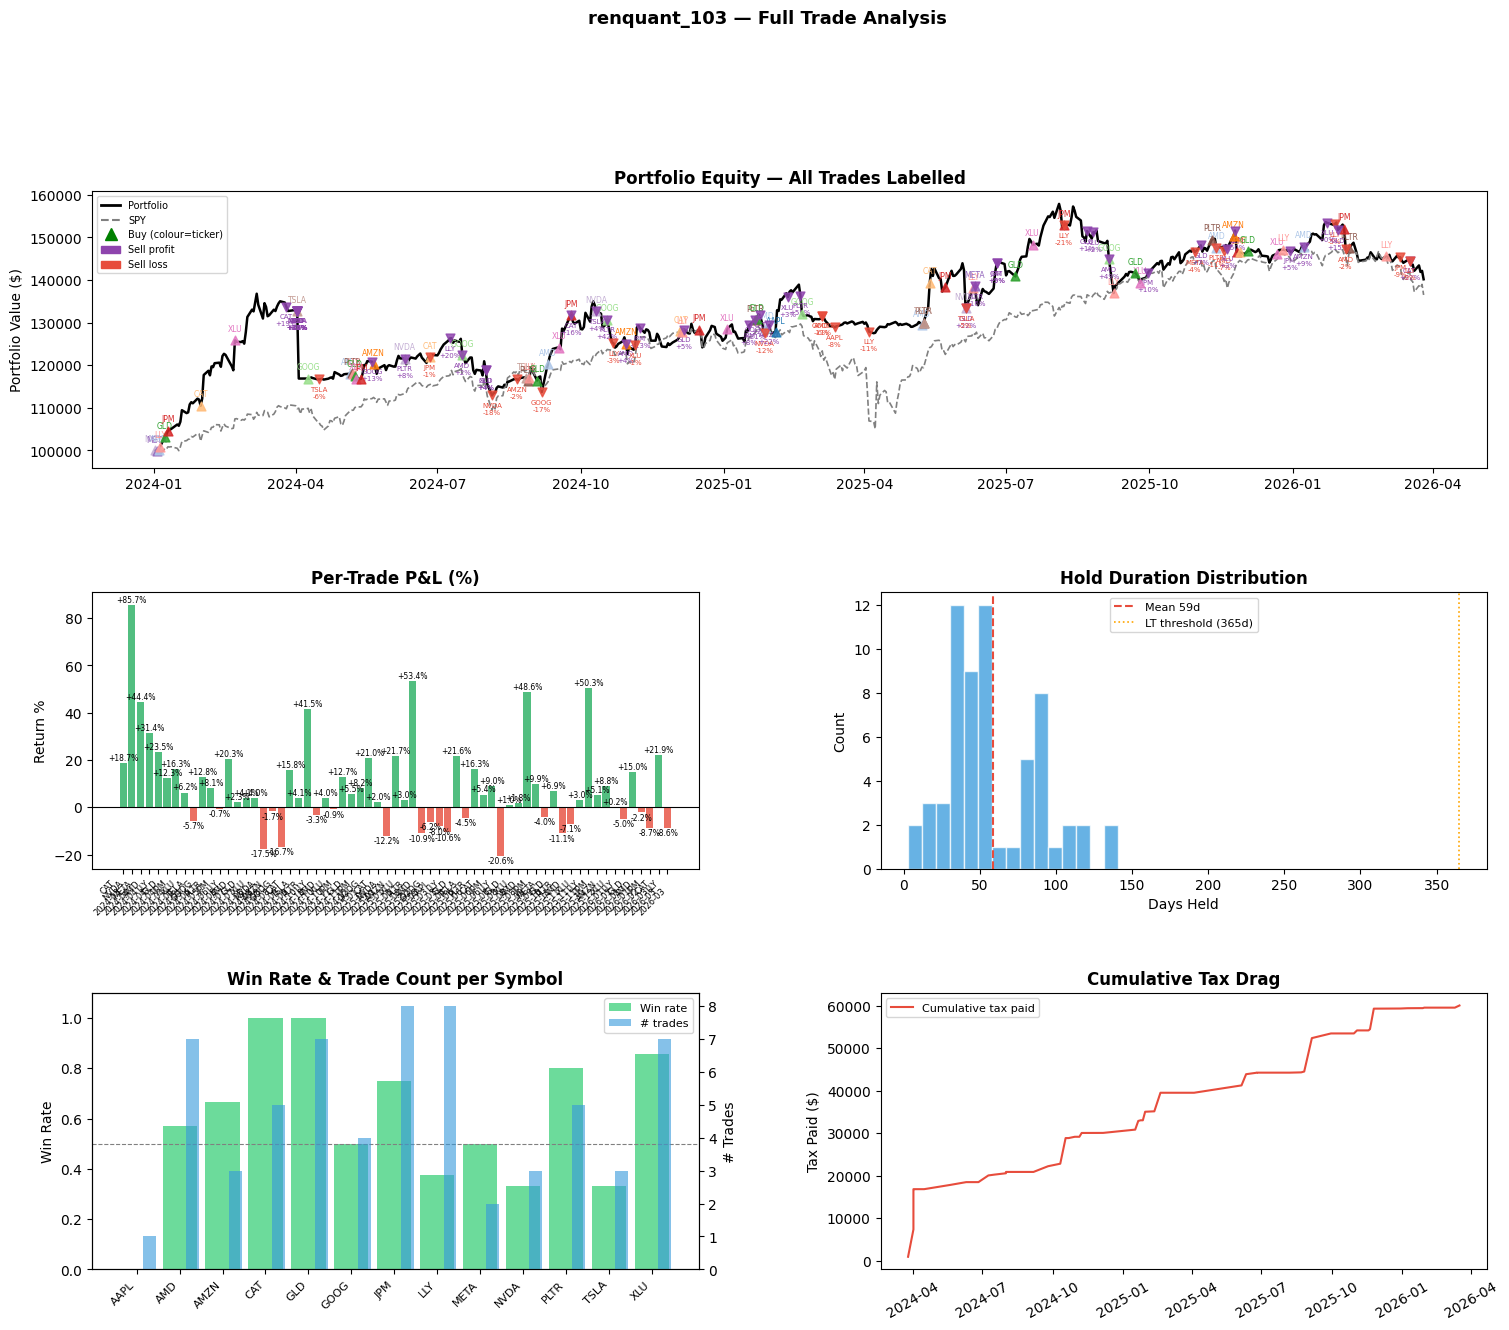

Saved → /Users/renhao/git/github/RenQuant/backtesting/renquant_103/img/trade_analysis.png


In [16]:
# ── Detailed trade chart: per-symbol equity + P&L bars + hold durations ──
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec

sells = [t for t in trade_log if t["action"] == "sell"]
buys  = [t for t in trade_log if t["action"] == "buy"]

if not sells and not buys:
    print("No trades to chart.")
else:
    tickers_traded = sorted(set([t["ticker"] for t in buys + sells]))
    colors_t = plt.cm.tab20.colors

    fig = plt.figure(figsize=(18, 14))
    gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.3)

    # ── Panel (0,0): Portfolio equity with per-ticker labeled buy/sell markers ──
    ax0 = fig.add_subplot(gs[0, :])
    ax0.plot(equity_df.index, equity_df["portfolio"], color="black", lw=1.8, label="Portfolio")
    ax0.plot(spy_norm.index, spy_norm.values, color="grey", lw=1.2, ls="--", label="SPY")

    ticker_colors = {t: colors_t[i % 20] for i, t in enumerate(tickers_traded)}
    for trade in buys:
        d = trade["date"]
        if d in equity_df.index:
            c = ticker_colors.get(trade["ticker"], "green")
            ax0.scatter(d, equity_df.loc[d, "portfolio"], marker="^", color=c,
                        s=40, zorder=5, alpha=0.85)
            ax0.annotate(trade["ticker"], xy=(d, equity_df.loc[d, "portfolio"]),
                         fontsize=5.5, color=c, ha="center", va="bottom",
                         xytext=(0, 5), textcoords="offset points")
    for trade in sells:
        d = trade["date"]
        if d in equity_df.index:
            c = "#e74c3c" if trade["pnl_pct"] < 0 else "#8e44ad"
            ax0.scatter(d, equity_df.loc[d, "portfolio"], marker="v", color=c,
                        s=40, zorder=5, alpha=0.85)
            ax0.annotate(f"{trade['ticker']}\n{trade['pnl_pct']:+.0%}",
                         xy=(d, equity_df.loc[d, "portfolio"]),
                         fontsize=5, color=c, ha="center", va="top",
                         xytext=(0, -5), textcoords="offset points")

    legend_handles = [
        plt.Line2D([0],[0],color="black",lw=2,label="Portfolio"),
        plt.Line2D([0],[0],color="grey",lw=1.5,ls="--",label="SPY"),
        plt.Line2D([0],[0],marker="^",color="green",lw=0,markersize=8,label="Buy (colour=ticker)"),
        mpatches.Patch(color="#8e44ad",label="Sell profit"),
        mpatches.Patch(color="#e74c3c",label="Sell loss"),
    ]
    ax0.legend(handles=legend_handles, fontsize=7, loc="upper left")
    ax0.set_title("Portfolio Equity — All Trades Labelled", fontweight="bold")
    ax0.set_ylabel("Portfolio Value ($)")

    # ── Panel (1,0): Per-trade P&L bar chart ──
    ax1 = fig.add_subplot(gs[1, 0])
    if sells:
        sells_sorted = sorted(sells, key=lambda x: x["date"])
        labels = [f"{t['ticker']}\n{str(t['date'])[:7]}" for t in sells_sorted]
        pnls   = [t["pnl_pct"] * 100 for t in sells_sorted]
        colors_bar = ["#e74c3c" if p < 0 else "#27ae60" for p in pnls]
        bars = ax1.bar(range(len(pnls)), pnls, color=colors_bar, alpha=0.8)
        ax1.set_xticks(range(len(pnls)))
        ax1.set_xticklabels(labels, fontsize=6, rotation=45, ha="right")
        ax1.axhline(0, color="black", lw=0.8)
        ax1.set_title("Per-Trade P&L (%)", fontweight="bold")
        ax1.set_ylabel("Return %")
        for bar, pnl in zip(bars, pnls):
            ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (0.3 if pnl >= 0 else -0.3),
                     f"{pnl:+.1f}%", ha="center", va="bottom" if pnl >= 0 else "top", fontsize=5.5)
    else:
        ax1.text(0.5, 0.5, "No completed trades", ha="center", va="center")

    # ── Panel (1,1): Hold duration histogram ──
    ax2 = fig.add_subplot(gs[1, 1])
    if sells:
        hold_days = [t["hold_days"] for t in sells]
        ax2.hist(hold_days, bins=15, color="#3498db", alpha=0.75, edgecolor="white")
        ax2.axvline(np.mean(hold_days), color="#e74c3c", lw=1.5, ls="--",
                    label=f"Mean {np.mean(hold_days):.0f}d")
        ax2.axvline(365, color="orange", lw=1.2, ls=":", label="LT threshold (365d)")
        ax2.legend(fontsize=8)
        ax2.set_title("Hold Duration Distribution", fontweight="bold")
        ax2.set_xlabel("Days Held")
        ax2.set_ylabel("Count")
    else:
        ax2.text(0.5, 0.5, "No completed trades", ha="center", va="center")

    # ── Panel (2,0): Per-symbol trade count & win rate ──
    ax3 = fig.add_subplot(gs[2, 0])
    if sells:
        sym_data = {}
        for t in sells:
            sym_data.setdefault(t["ticker"], {"wins":0,"total":0})
            sym_data[t["ticker"]]["total"] += 1
            if t["pnl_pct"] > 0:
                sym_data[t["ticker"]]["wins"] += 1
        syms = sorted(sym_data)
        win_rates = [sym_data[s]["wins"] / sym_data[s]["total"] for s in syms]
        counts    = [sym_data[s]["total"] for s in syms]
        x = range(len(syms))
        ax3.bar(x, win_rates, color="#2ecc71", alpha=0.7, label="Win rate")
        ax3_r = ax3.twinx()
        ax3_r.bar([i + 0.3 for i in x], counts, width=0.3, color="#3498db", alpha=0.6, label="# trades")
        ax3.set_xticks(x); ax3.set_xticklabels(syms, rotation=45, ha="right", fontsize=8)
        ax3.set_ylim(0, 1.1); ax3.axhline(0.5, color="grey", lw=0.8, ls="--")
        ax3.set_title("Win Rate & Trade Count per Symbol", fontweight="bold")
        ax3.set_ylabel("Win Rate")
        ax3_r.set_ylabel("# Trades")
        lines1, labels1 = ax3.get_legend_handles_labels()
        lines2, labels2 = ax3_r.get_legend_handles_labels()
        ax3.legend(lines1+lines2, labels1+labels2, fontsize=8)

    # ── Panel (2,1): Cumulative tax paid vs gross P&L ──
    ax4 = fig.add_subplot(gs[2, 1])
    if sells:
        sells_sorted = sorted(sells, key=lambda x: x["date"])
        dates        = [t["date"] for t in sells_sorted]
        cum_tax      = np.cumsum([t["tax"] for t in sells_sorted])
        cum_gross_pnl = np.cumsum([t["pnl_pct"] * INITIAL_CASH / max(1, len(sells_sorted))
                                   for t in sells_sorted])
        ax4.plot(dates, cum_tax, color="#e74c3c", lw=1.5, label="Cumulative tax paid")
        ax4.set_title("Cumulative Tax Drag", fontweight="bold")
        ax4.set_ylabel("Tax Paid ($)")
        ax4.legend(fontsize=8)
        ax4.tick_params(axis="x", rotation=30)

    plt.suptitle("renquant_103 — Full Trade Analysis", fontsize=13, fontweight="bold", y=1.01)
    plt.savefig(STRATEGY_DIR / "img" / "trade_analysis.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved → {STRATEGY_DIR / 'img' / 'trade_analysis.png'}")


## 11  Per-Symbol OOS Equity Curves

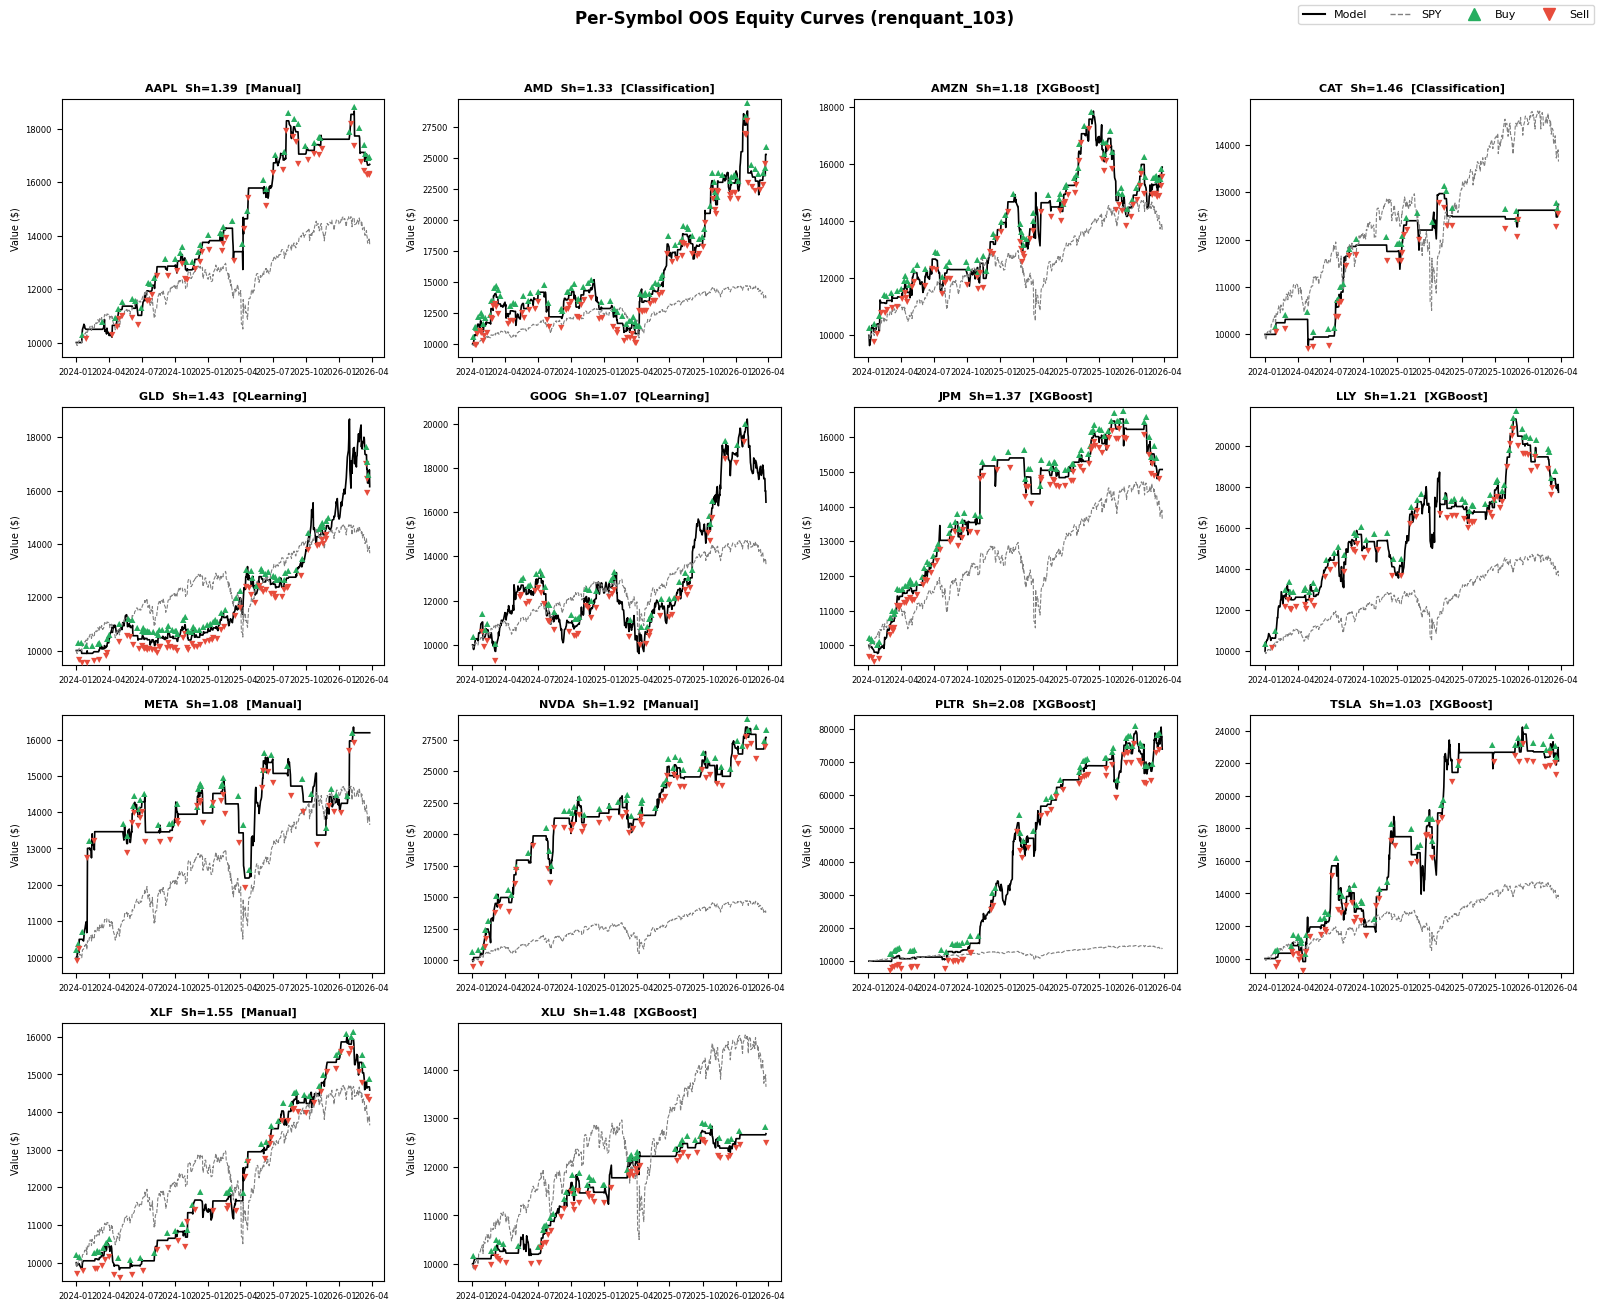

In [17]:
pass_tickers = sorted([t for t, r in results.items() if r.get("passes_floor")])

# Also include bootstrapped models that exist on disk
import json as _json
from pathlib import Path as _Path
model_dir = STRATEGY_DIR / "models"
for ticker in WATCHLIST:
    if ticker in pass_tickers:
        continue
    meta = model_dir / ticker / f"{ticker}-policy-metadata.json"
    if meta.exists():
        with meta.open() as _f:
            _m = _json.load(_f)
        if ticker not in results:
            results[ticker] = {
                "sharpe": _m.get("sharpe", 0),
                "best_approach": _m.get("best_approach", "bootstrapped"),
                "passes_floor": True,
                "oos_signals": None,
                "oos_prices": ohlcv.get(ticker, pd.DataFrame())["close"] if ticker in ohlcv else pd.Series(),
                "oos_rows": 0,
            }
            pass_tickers.append(ticker)

pass_tickers = sorted(set(pass_tickers))

if not pass_tickers:
    print("No models available — run Section 5 (training) first.")
else:
    ncols = 4
    nrows = max(1, (len(pass_tickers) + ncols - 1) // ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3.2))
    axes = np.array(axes).flatten()

    spy_oos_close = spy_df["close"].loc[BACKTEST_START:BACKTEST_END]

    for i, ticker in enumerate(pass_tickers):
        ax     = axes[i]
        r      = results[ticker]
        sigs   = r["oos_signals"]
        prices = r["oos_prices"].loc[BACKTEST_START:BACKTEST_END]

        if sigs is None or prices.empty:
            ax.set_title(f"{ticker} — no OOS data", fontsize=8); continue

        sigs_bt = sigs.reindex(prices.index).fillna(0)
        try:
            pos       = sigs_bt.clip(0, 1).shift(1).fillna(0)
            strat_ret = prices.pct_change().fillna(0) * pos
            pv        = 10_000 * (1 + strat_ret).cumprod()
            spy_sub   = spy_oos_close.reindex(prices.index)
            spy_sub   = spy_sub / spy_sub.iloc[0] * 10_000

            ax.plot(pv.index,      pv.values,      color="black", lw=1.2, label="Model")
            ax.plot(spy_sub.index, spy_sub.values, color="grey",  lw=0.8, ls="--", label="SPY")

            # Buy/sell markers from signal transitions
            prev_sig = 0.0
            for dt in pv.index:
                cur_sig = float(sigs_bt.loc[dt]) if dt in sigs_bt.index else 0.0
                pv_val  = float(pv.loc[dt])
                if prev_sig != 1.0 and cur_sig == 1.0:   # entry
                    ax.annotate("▲", xy=(dt, pv_val), fontsize=6, color="#27ae60",
                                ha="center", va="bottom",
                                xytext=(0, 3), textcoords="offset points")
                elif prev_sig == 1.0 and cur_sig != 1.0:  # exit
                    ax.annotate("▼", xy=(dt, pv_val), fontsize=6, color="#e74c3c",
                                ha="center", va="top",
                                xytext=(0, -3), textcoords="offset points")
                prev_sig = cur_sig

            ax.set_title(f"{ticker}  Sh={r['sharpe']:.2f}  [{r['best_approach']}]",
                         fontsize=8, fontweight="bold")
            ax.set_ylabel("Value ($)", fontsize=7)
            ax.tick_params(labelsize=6)
        except Exception as e:
            ax.set_title(f"{ticker} — error: {e}", fontsize=7)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    # Shared legend
    fig.legend(handles=[
        plt.Line2D([0],[0], color="black", lw=1.5, label="Model"),
        plt.Line2D([0],[0], color="grey",  lw=1,   ls="--", label="SPY"),
        plt.Line2D([0],[0], marker="^", color="#27ae60", lw=0, markersize=8, label="Buy"),
        plt.Line2D([0],[0], marker="v", color="#e74c3c", lw=0, markersize=8, label="Sell"),
    ], loc="upper right", fontsize=8, ncol=4)

    plt.suptitle("Per-Symbol OOS Equity Curves (renquant_103)", fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig(STRATEGY_DIR / "img" / "per_symbol_oos.png", dpi=150, bbox_inches="tight")
    plt.show()


## 12  Fetch Earnings Calendar (run once)

In [18]:
# Run this cell to refresh the earnings calendar artifact.
# Can also run: python scripts/fetch_earnings_calendar.py --strategy renquant_103

import subprocess, sys
result = subprocess.run(
    [sys.executable, str(ROOT / "scripts" / "fetch_earnings_calendar.py"),
     "--strategy", STRATEGY, "--lookahead", "90"],
    capture_output=True, text=True
)
print(result.stdout)
if result.returncode != 0:
    print("STDERR:", result.stderr)


Fetching earnings calendar for 23 symbols → /Users/renhao/git/github/RenQuant/backtesting/renquant_103/artifacts/earnings-calendar.json
  TSLA... 1 dates
  AMZN... 1 dates
  GOOG... 1 dates
  MSFT... 1 dates
  AMD... 1 dates
  NFLX... 2 dates
  CRM... 1 dates
  PLTR... 1 dates
  UBER... 1 dates
  NVDA... 1 dates
  META... 1 dates
  AAPL... 1 dates
  JPM... 2 dates
  UNH... 1 dates
  CAT... 1 dates
  BA... 1 dates
  XLE... 0 dates
  XLF... 0 dates
  LLY... 1 dates
  GLD... 0 dates
  TLT... 0 dates
  XLV... 0 dates
  XLU... 0 dates

Saved → /Users/renhao/git/github/RenQuant/backtesting/renquant_103/artifacts/earnings-calendar.json



## Done

Next steps:
1. Review regime charts (Section 3) — do the regime transitions make intuitive sense?
2. Check per-symbol Sharpe table (Section 8) — any symbols you want to add/remove?
3. Export LEAN data: `python scripts/export_lean_watchlist.py --strategy renquant_103`
4. Run LEAN backtest: `cd backtesting/renquant_103 && lean backtest .`
5. Analyse: `python scripts/analyze_backtest.py --strategy renquant_103`